# Analyse des variables qualitatives et quantitatives

## Bibliothèques importés

In [4]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Fonction connection BDD

In [5]:
def getBDD():
    try:
        return mysql.connector.connect(
            host='localhost', database='gamesale',
            user='root', password='', charset='utf8'
        )
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

## Fonction pour l'analyse de la variable Année et une variable quantitative

In [16]:
def plot_boxplot_annee(numeric_col, label_x="Année", label_y="Valeur"):
    connect = getBDD()
    if not connect: return

    sql = f"SELECT annee, {numeric_col} FROM jeux"
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')
    
    df['annee'] = df['annee'].astype(str).str.strip()
    df = df[df['annee'] != '']
    df = df[df['annee'].str.lower() != 'nan']
    df = df.dropna(subset=[numeric_col, 'annee'])

    df['annee'] = pd.to_numeric(df['annee']).astype(int)

    upper_limit = df[numeric_col].quantile(0.90)
    df = df[df[numeric_col] <= upper_limit]

    counts = df['annee'].value_counts()
    valid_years = counts[counts >= 7].index
    df = df[df['annee'].isin(valid_years)]
    year_order = sorted(df['annee'].unique())

    plt.figure(figsize=(15, 7))
    
    sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)
    plt.title(f'Distribution de {numeric_col} par Année (Top 10% outliers supprimés)', fontsize=15)
    plt.xlabel(label_x, fontsize=12)
    plt.ylabel(label_y, fontsize=12)
    
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    return df

## Année et Ventes globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


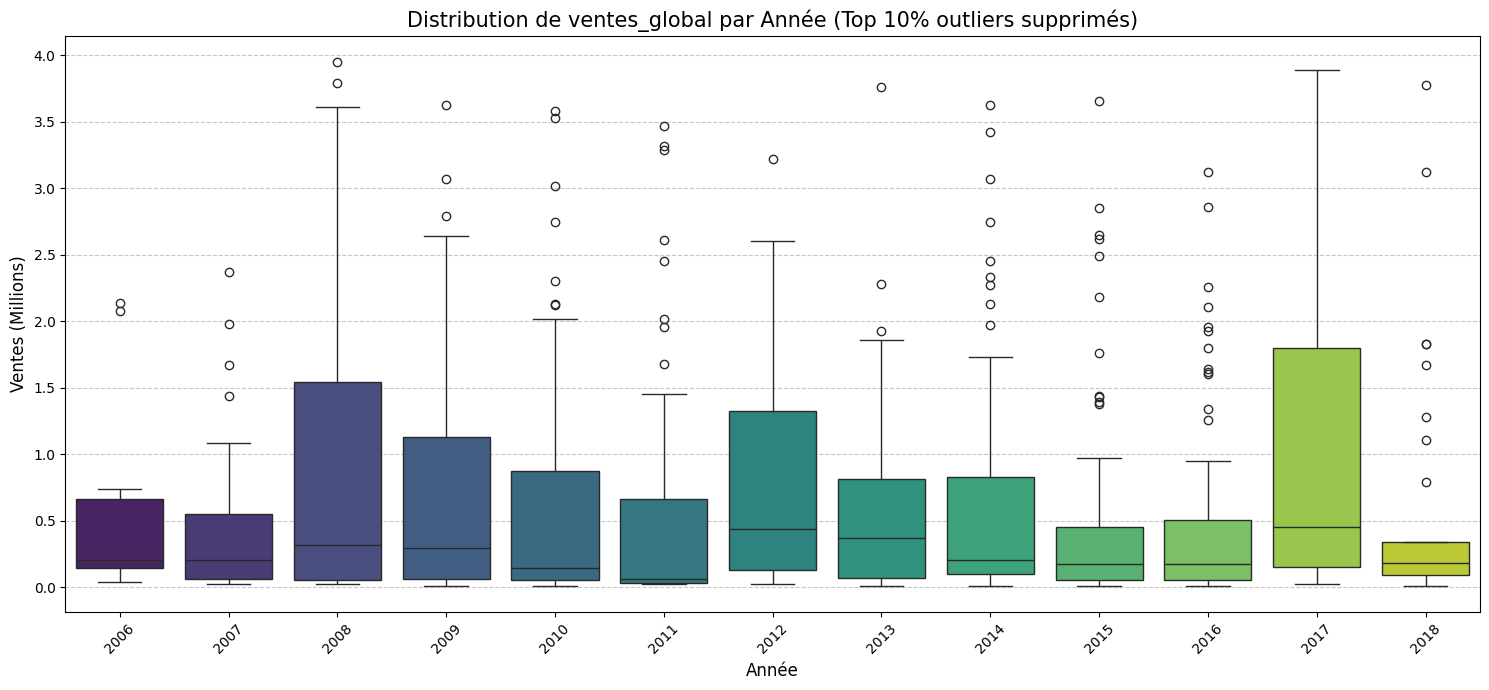

,annee,ventes_global
34,2008,3.54
38,2008,3.42
45,2017,3.20
46,2018,3.12
52,2008,3.61
...,...,...
771,2009,0.01
772,2009,0.01
773,2009,0.01
774,2015,0.01


In [17]:
plot_boxplot_annee('ventes_global', "Année", "Ventes (Millions)")

## Année et Ventes en Amérique du Nord

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


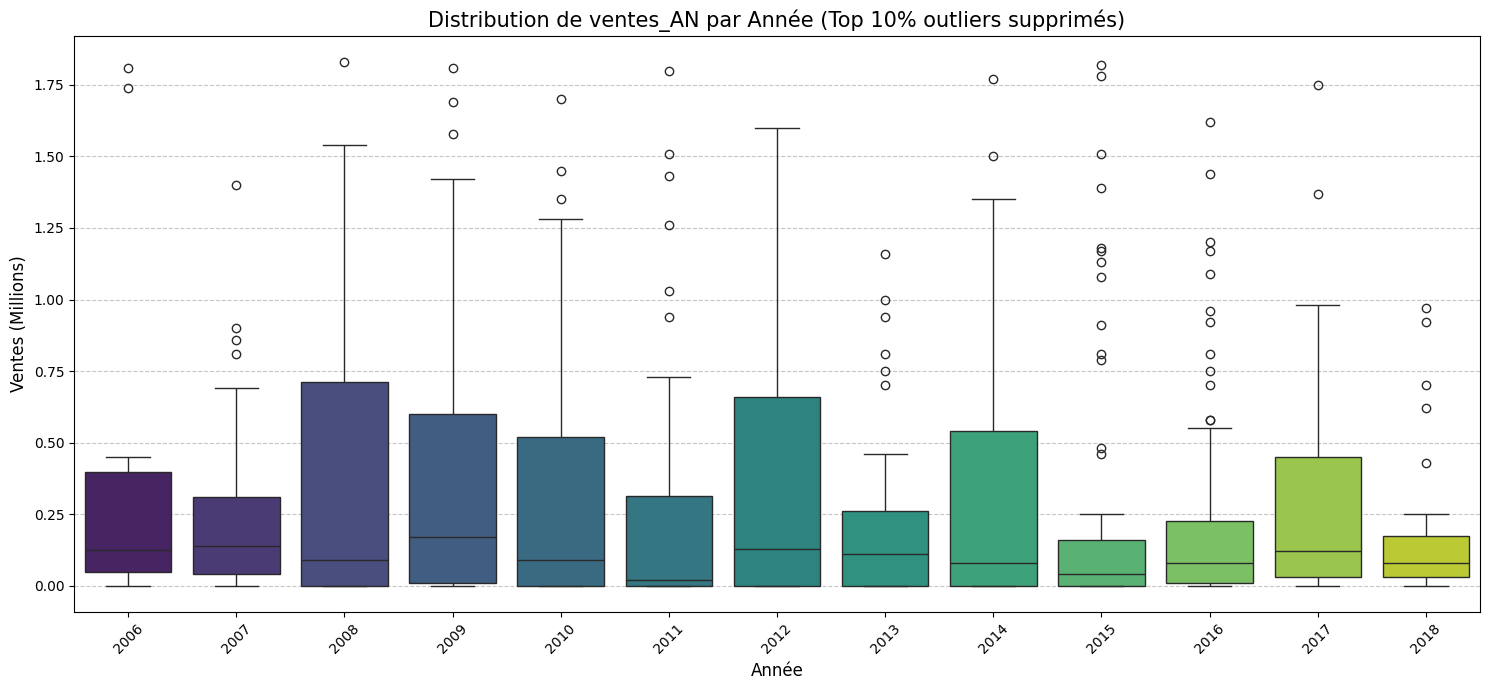

,annee,ventes_AN
18,2016,1.62
32,2015,1.82
38,2008,1.13
39,2014,1.77
41,2015,1.78
...,...,...
771,2009,0.00
772,2009,0.00
773,2009,0.00
774,2015,0.00


In [18]:
plot_boxplot_annee('ventes_AN', "Année", "Ventes (Millions)")

## Année et Ventes en Europe

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


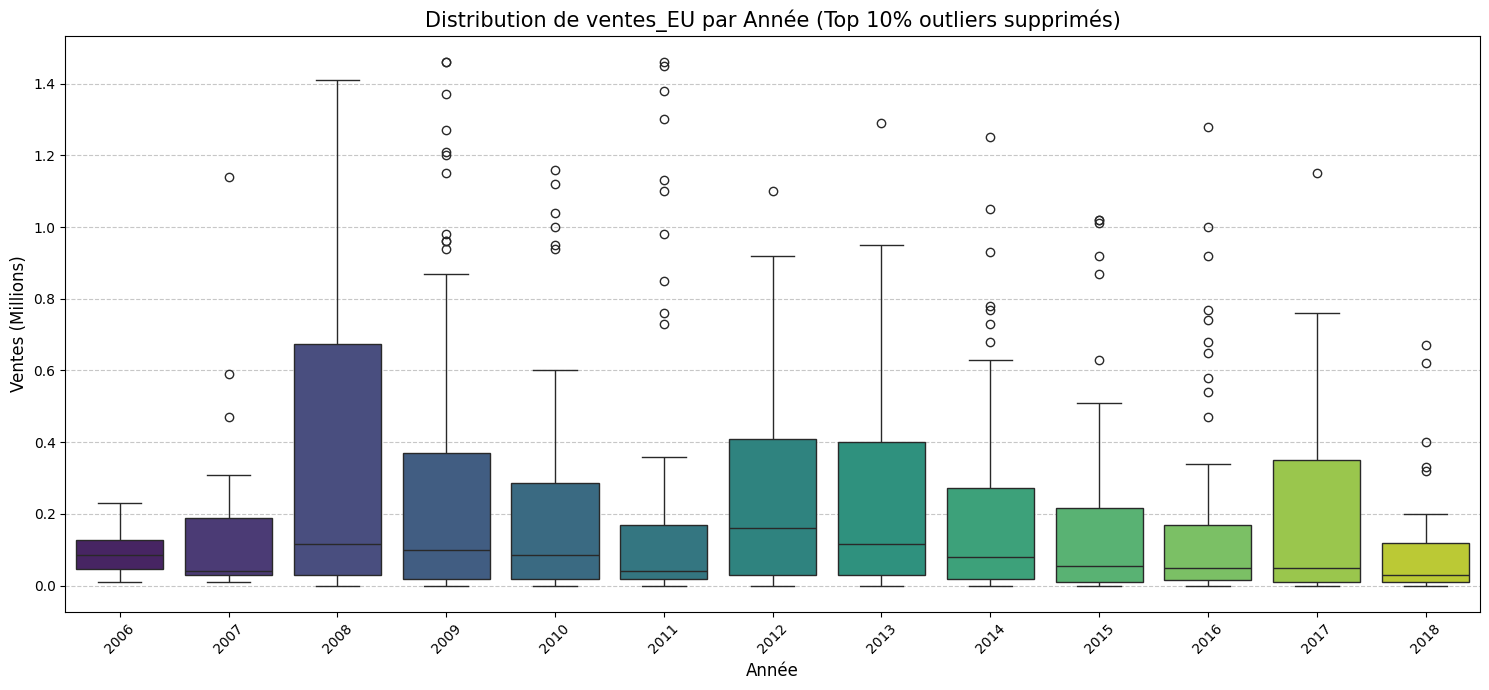

,annee,ventes_EU
18,2016,0.77
27,2009,1.21
34,2008,0.52
35,2011,1.30
39,2014,0.05
...,...,...
771,2009,0.01
772,2009,0.01
773,2009,0.01
774,2015,0.01


In [19]:
plot_boxplot_annee('ventes_EU', "Année", "Ventes (Millions)")

## Année et Ventes au Japon

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


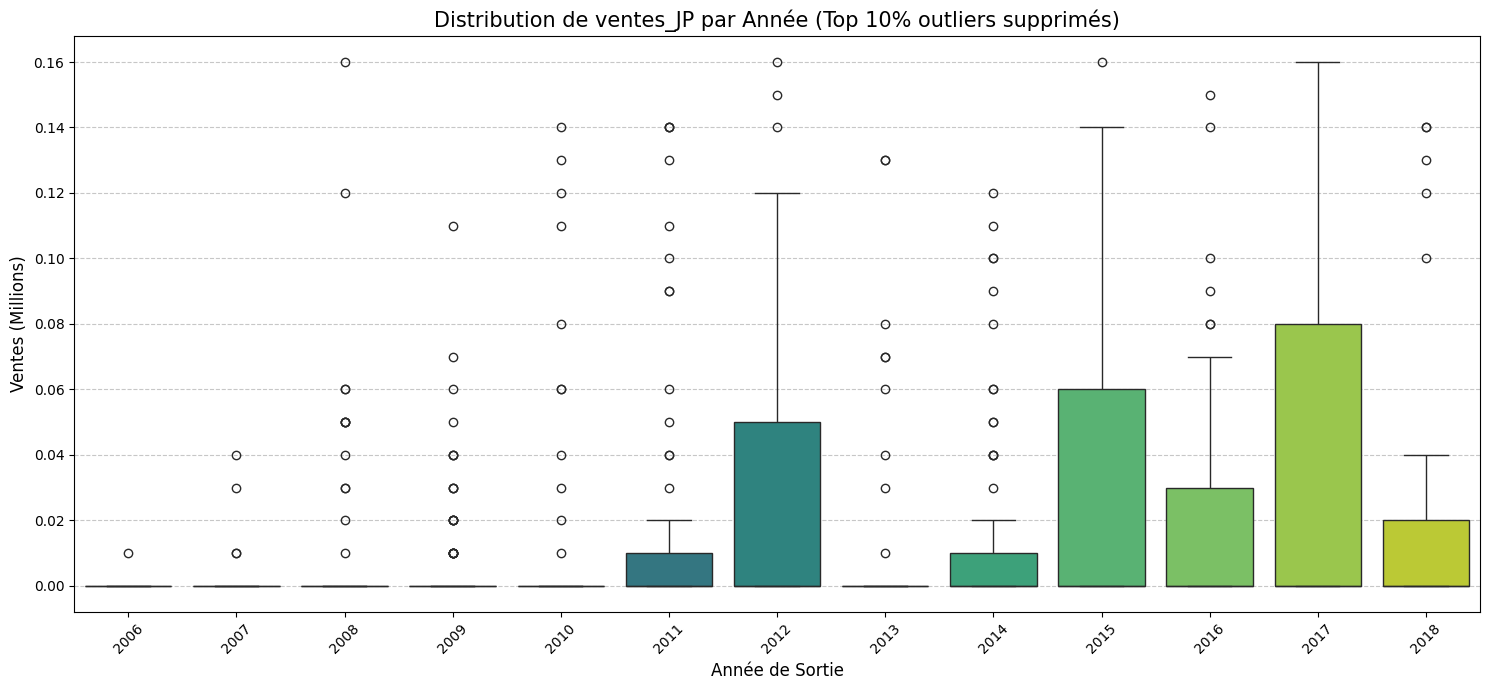

,annee,ventes_JP
12,2011,0.05
14,2008,0.00
16,2009,0.00
20,2008,0.16
21,2013,0.13
...,...,...
771,2009,0.00
772,2009,0.00
773,2009,0.00
774,2015,0.00


In [20]:
plot_boxplot_annee('ventes_JP', "Année de Sortie", "Ventes (Millions)")

## Année et Autres Ventes

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


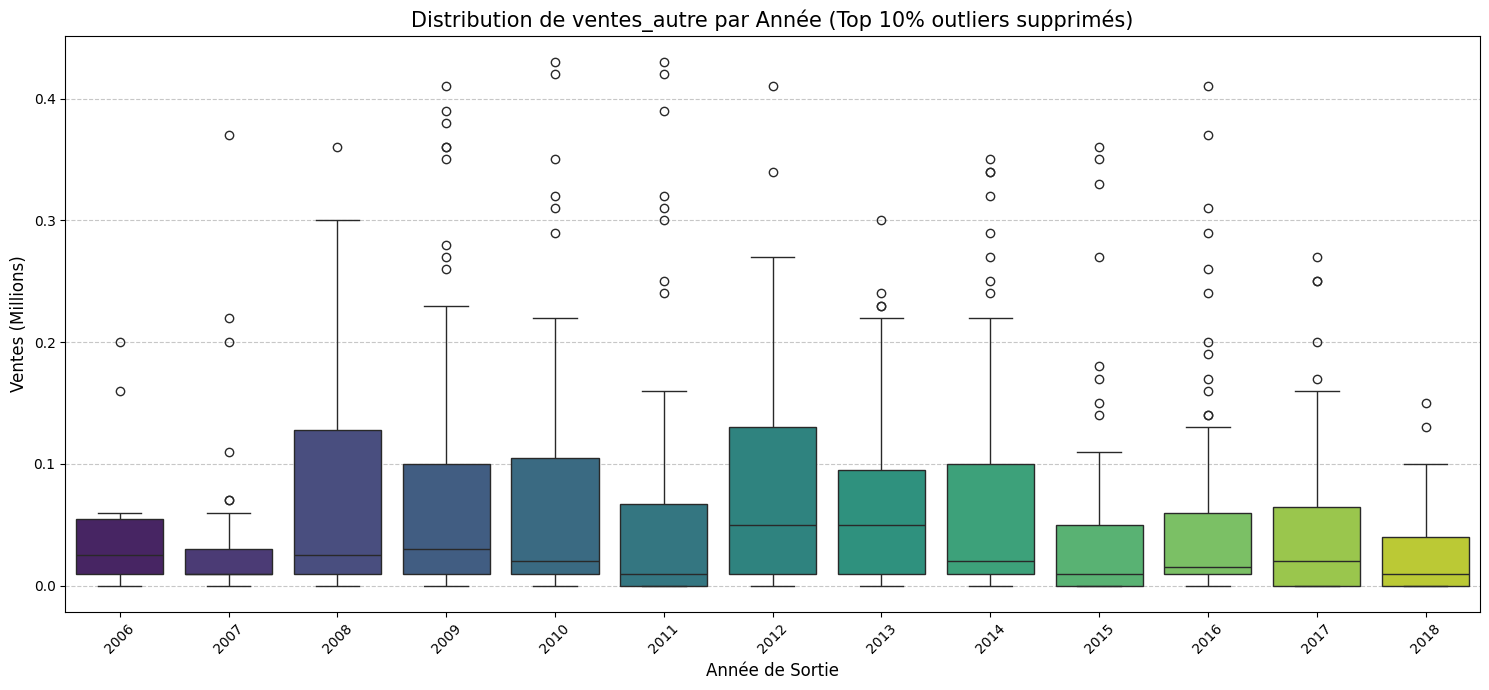

,annee,ventes_autre
13,2013,0.23
18,2016,0.14
19,2012,0.41
21,2013,0.24
27,2009,0.41
...,...,...
771,2009,0.00
772,2009,0.00
773,2009,0.00
774,2015,0.00


In [21]:
plot_boxplot_annee('ventes_autre', "Année de Sortie", "Ventes (Millions)")

## Année et Prix

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\4213011030.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='annee', y=numeric_col, order=year_order, palette='viridis', showfliers=True)


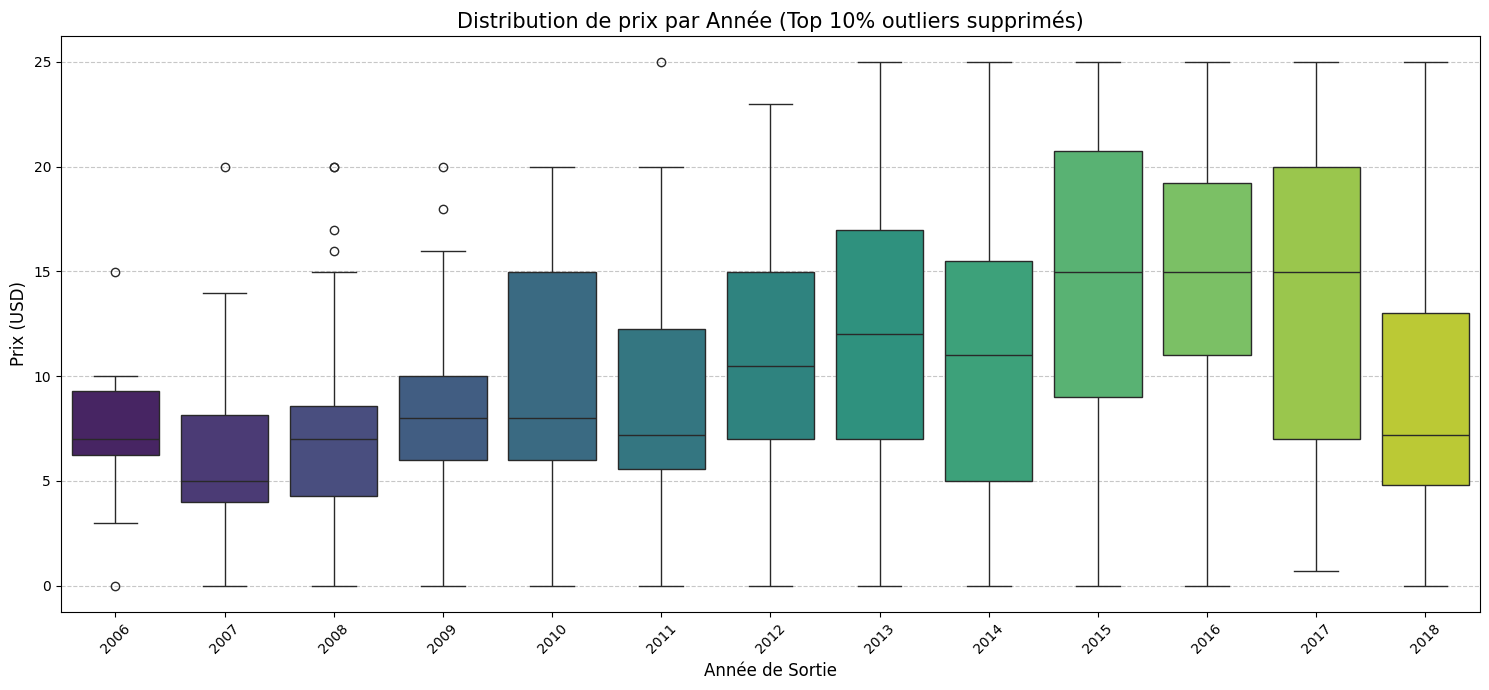

,annee,prix
0,2015,24.99
1,2008,9.99
2,2011,5.99
5,2009,19.99
6,2008,5.99
...,...,...
771,2009,3.49
772,2009,15.99
773,2009,9.99
774,2015,8.99


In [22]:
plot_boxplot_annee('prix', "Année de Sortie", "Prix (USD)")

## Fonction pour l'analyse des Genres et une variable quantitative

In [24]:
def plot_boxplot_genres(numeric_col, label_x="Genre", label_y="Valeur"):
    connect = getBDD()
    if not connect: return

    sql = f"""
        SELECT genre.genre, jeux.{numeric_col} 
        FROM jeux 
        JOIN genre ON jeux.id_jeu = genre.id_jeu
    """
    
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

    df['genre'] = df['genre'].astype(str).str.strip()
    df = df[df['genre'] != '']
    df = df[df['genre'].str.lower() != 'nan']
    
    df = df.dropna(subset=[numeric_col, 'genre'])

    upper_limit = df[numeric_col].quantile(0.90)
    df = df[df[numeric_col] <= upper_limit]

    counts = df['genre'].value_counts()
    valid_genres = counts[counts >= 7].index
    df = df[df['genre'].isin(valid_genres)]
    
    order = df.groupby('genre')[numeric_col].median().sort_values(ascending=False).index

    plt.figure(figsize=(14, 8))
    
    sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')

    plt.title(f'Distribution de {numeric_col} par Genre (Top 10% outliers supprimés)', fontsize=15)
    plt.xlabel(label_x, fontsize=12, fontweight='bold')
    plt.ylabel(label_y, fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    return df

## Genres et Ventes globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


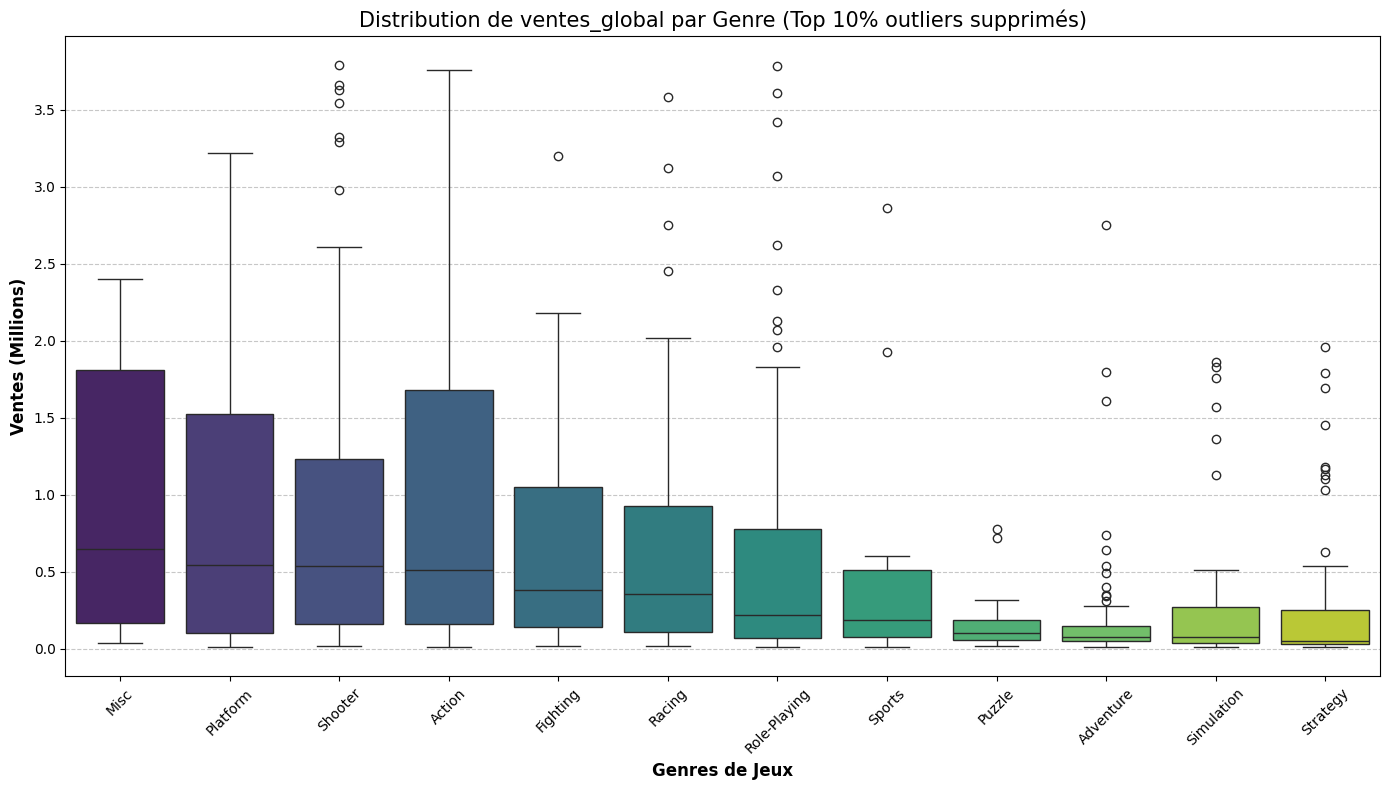

,genre,ventes_global
34,Shooter,3.54
38,Action,3.42
45,Fighting,3.20
46,Racing,3.12
52,Role-Playing,3.61
...,...,...
771,Strategy,0.01
772,Sports,0.01
773,Strategy,0.01
774,Adventure,0.01


In [25]:
plot_boxplot_genres('ventes_global', "Genres de Jeux", "Ventes (Millions)")

## Genres et Ventes au Amerique du Nord

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


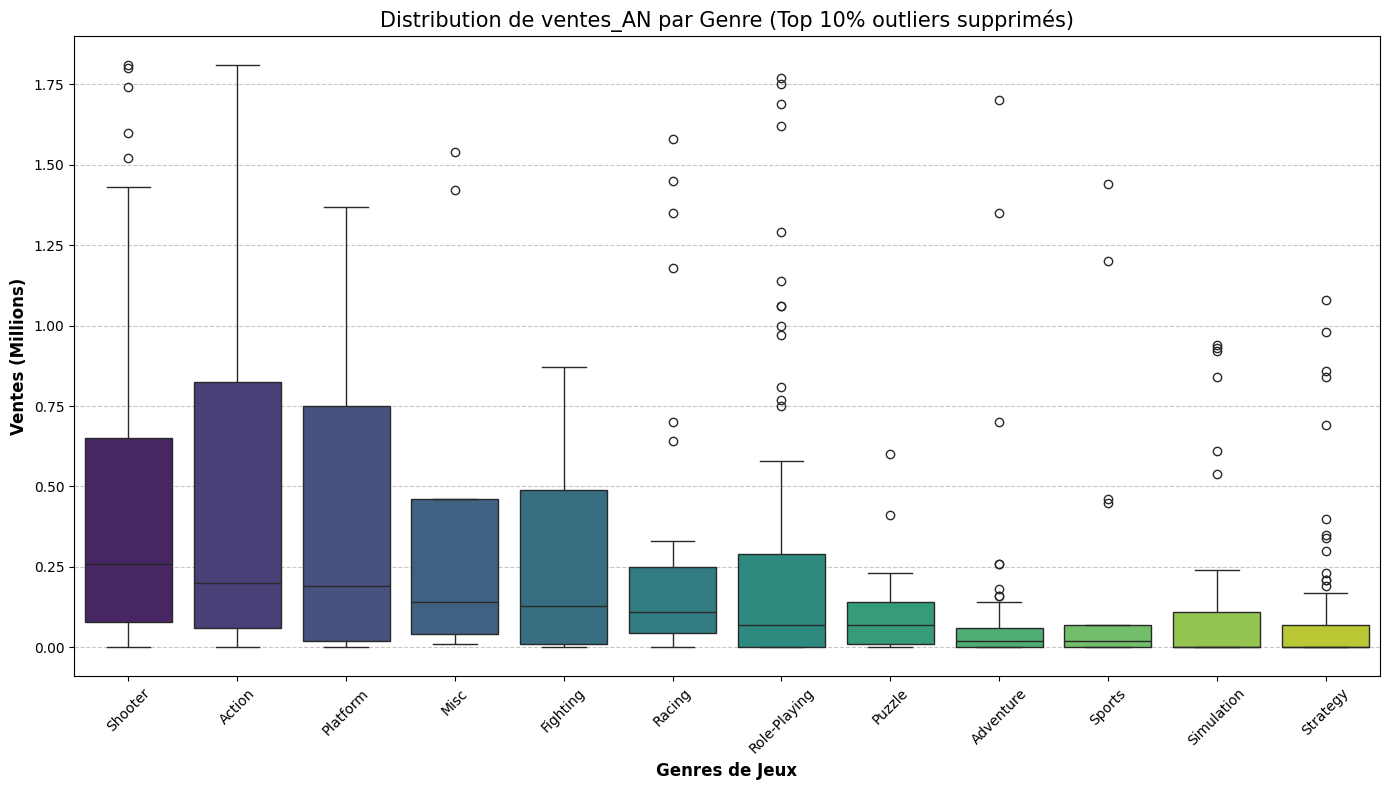

,genre,ventes_AN
18,Role-Playing,1.62
38,Action,1.13
39,Role-Playing,1.77
41,Action,1.78
43,Action,1.51
...,...,...
771,Strategy,0.00
772,Sports,0.00
773,Strategy,0.00
774,Adventure,0.00


In [27]:
plot_boxplot_genres('ventes_AN', "Genres de Jeux", "Ventes (Millions)")

## Genres et Ventes en Europe

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


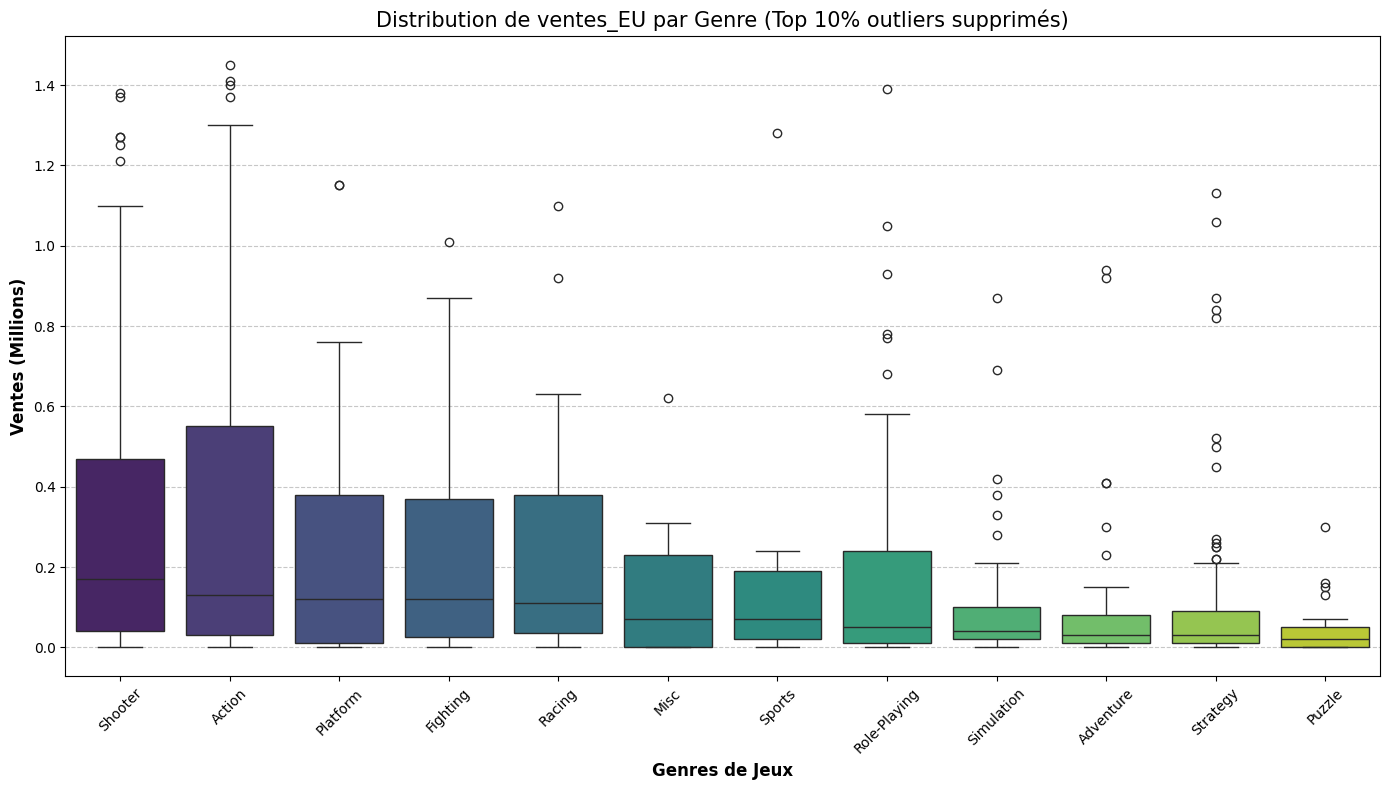

,genre,ventes_EU
18,Role-Playing,0.77
24,Shooter,0.23
27,Shooter,1.21
34,Shooter,0.52
35,Action,1.30
...,...,...
771,Strategy,0.01
772,Sports,0.01
773,Strategy,0.01
774,Adventure,0.01


In [26]:
plot_boxplot_genres('ventes_EU', "Genres de Jeux", "Ventes (Millions)")

## Genres et Ventes au Japon

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


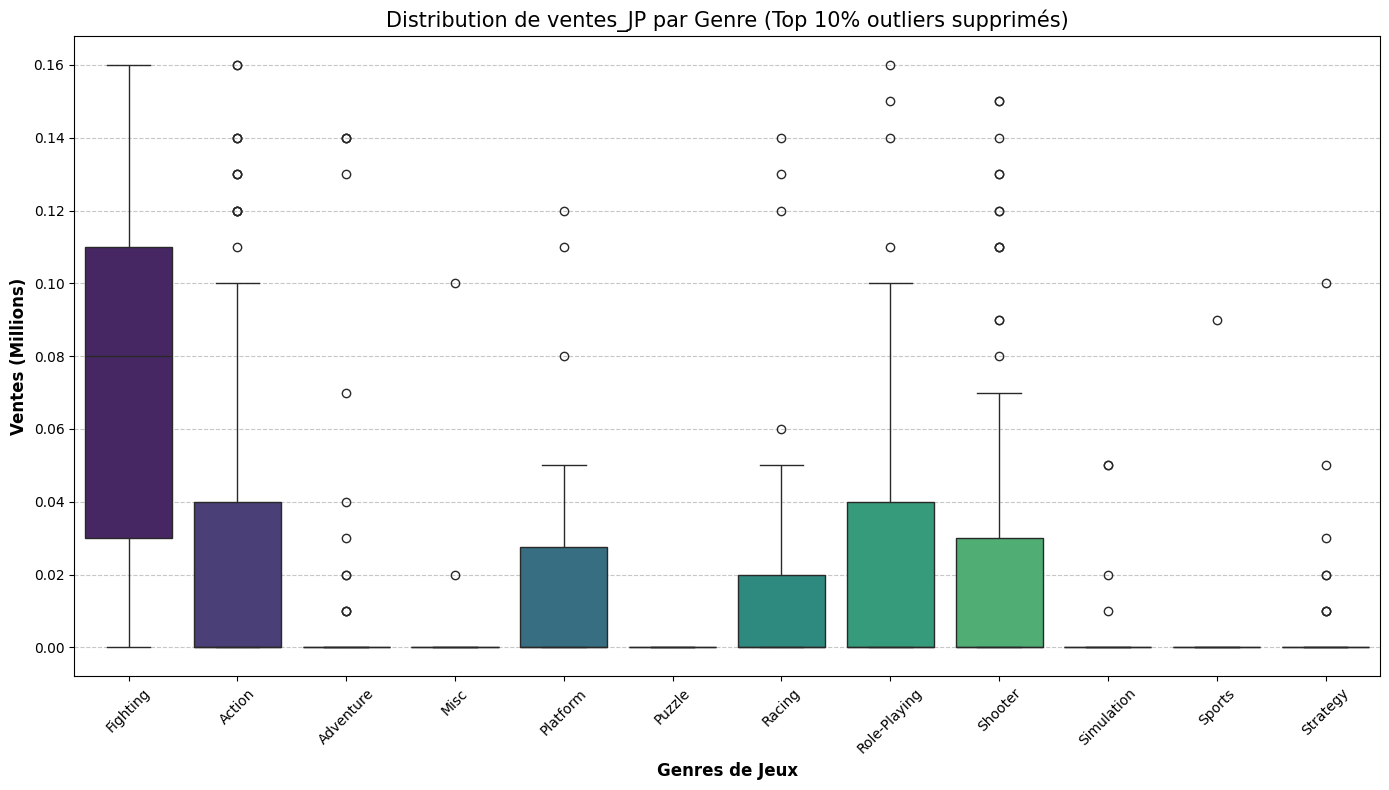

,genre,ventes_JP
12,Simulation,0.05
14,Shooter,0.00
16,Action,0.00
20,Role-Playing,0.16
21,Action,0.13
...,...,...
771,Strategy,0.00
772,Sports,0.00
773,Strategy,0.00
774,Adventure,0.00


In [28]:
plot_boxplot_genres('ventes_JP', "Genres de Jeux", "Ventes (Millions)")

## Genres et Autres ventes

C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_20624\3619499104.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


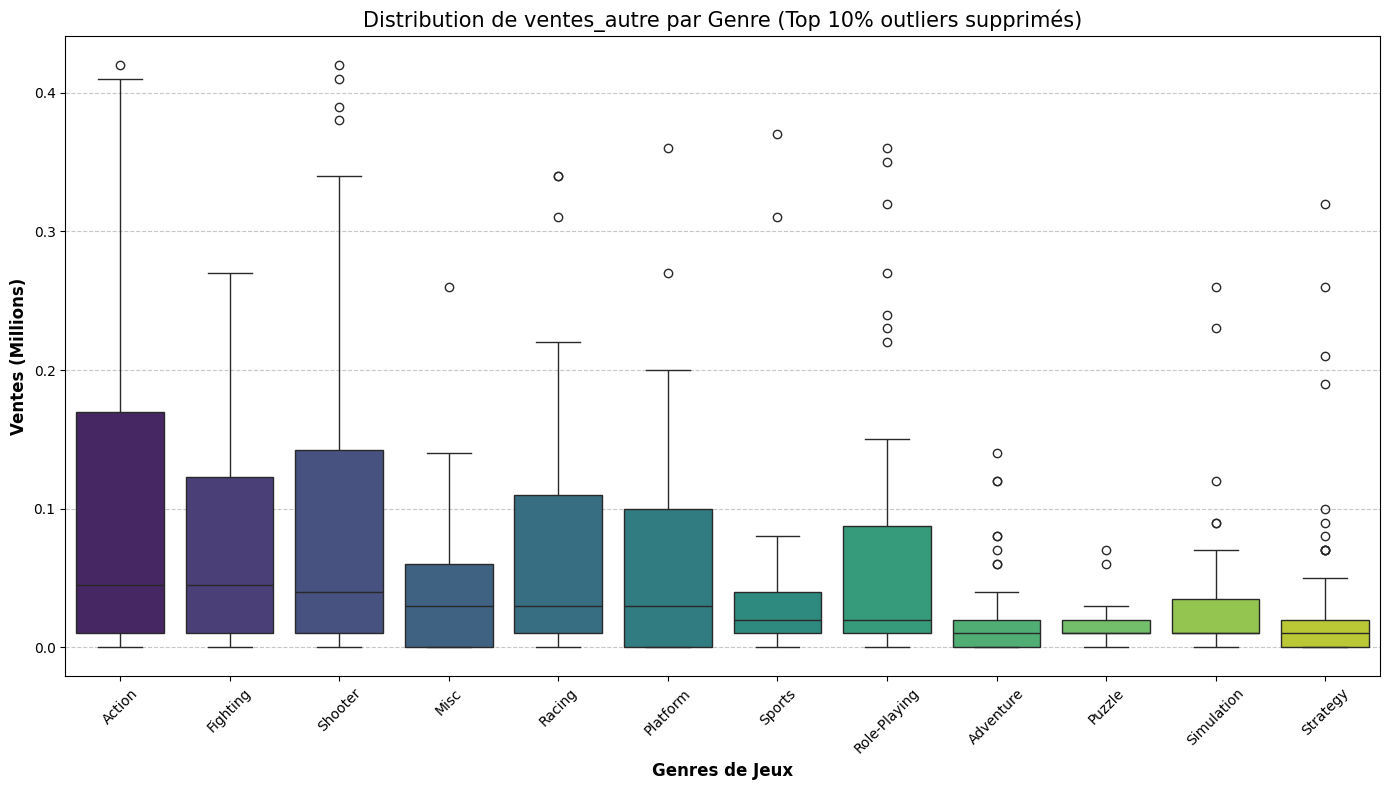

In [44]:
plot_boxplot_genres('ventes_autre', "Genres de Jeux", "Ventes (Millions)")

## Genres et Prix

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\3468879583.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y=numeric_col, order=order, palette='viridis')


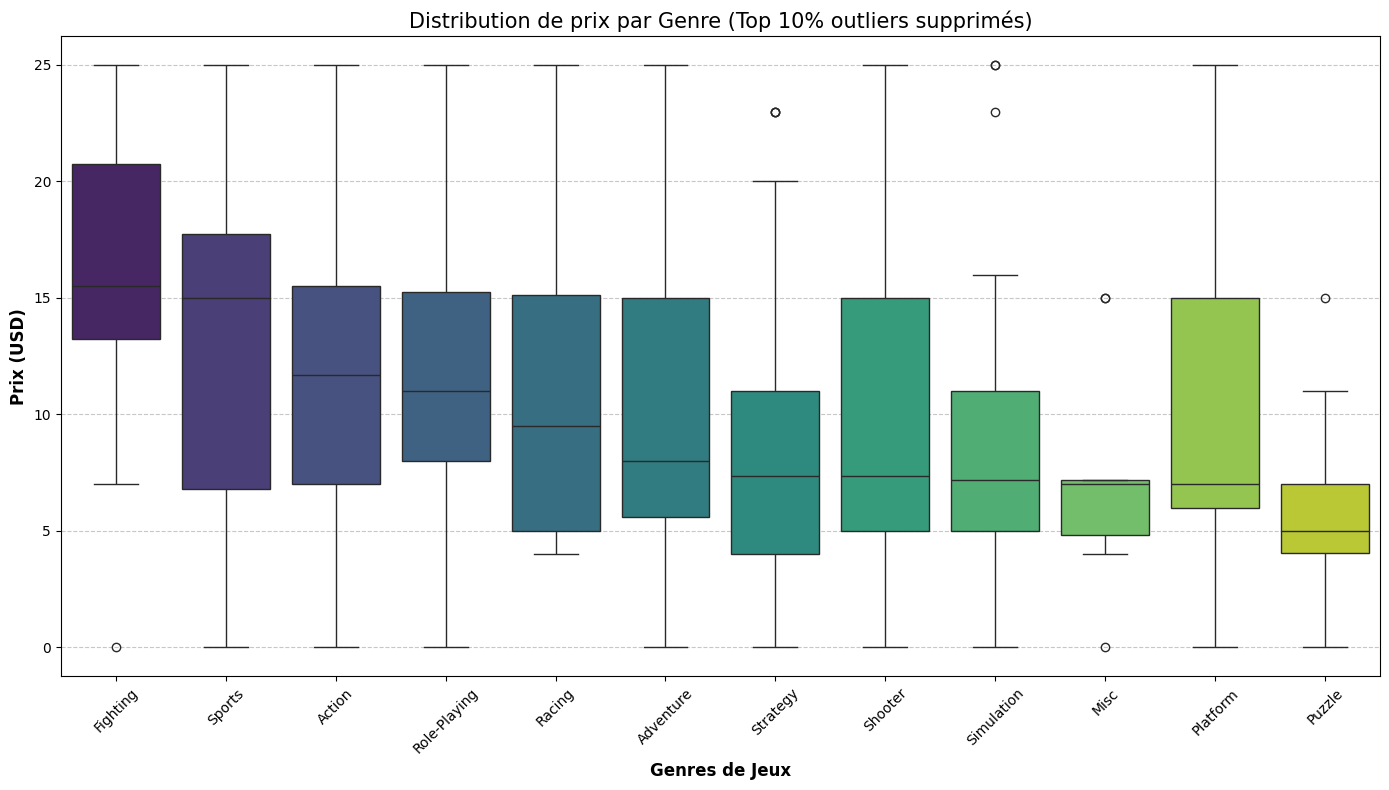

,genre,prix
0,Action,24.99
1,Action,9.99
2,Action,5.99
5,Shooter,19.99
6,Action,5.99
...,...,...
771,Strategy,3.49
772,Sports,15.99
773,Strategy,9.99
774,Adventure,8.99


In [29]:
plot_boxplot_genres('prix', "Genres de Jeux", "Prix (USD)")

## Fonction pour l'analyse des éditeurs et une variable quantitative

In [30]:
def plot_boxplot_editeur_top30(numeric_col, label_x="Ventes", label_y="Éditeur"):
    connect = getBDD()
    if not connect: return

    sql = f"SELECT editeur.editeur, jeux.{numeric_col} FROM jeux JOIN editeur ON jeux.id_jeu = editeur.id_jeu"
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

    df['editeur'] = df['editeur'].astype(str).str.strip()
    
    df['editeur'] = df['editeur'].str.split(';')
    df = df.explode('editeur')

    df['editeur'] = df['editeur'].str.strip()
    df['editeur'] = df['editeur'].str.title() 

    df = df[df['editeur'] != '']
    df = df[df['editeur'].str.lower() != 'nan']
    df = df.dropna(subset=[numeric_col, 'editeur'])

    top_30= df.groupby('editeur')[numeric_col].mean().sort_values(ascending=False).head(30).index
    df_top30 = df[df['editeur'].isin(top_30)]

    plt.figure(figsize=(12, 10))
    sns.boxplot(data=df_top30, y='editeur', x=numeric_col, order=top_30, palette='viridis')

    plt.title(f'Top 30 Éditeurs par moyenne de {numeric_col}', fontsize=14)
    plt.xlabel(label_x, fontsize=12)
    plt.ylabel(label_y, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    return df_top30

## Top 30 des Editeurs par moyenne des Ventes globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='editeur', x=numeric_col, order=top_30, palette='viridis')


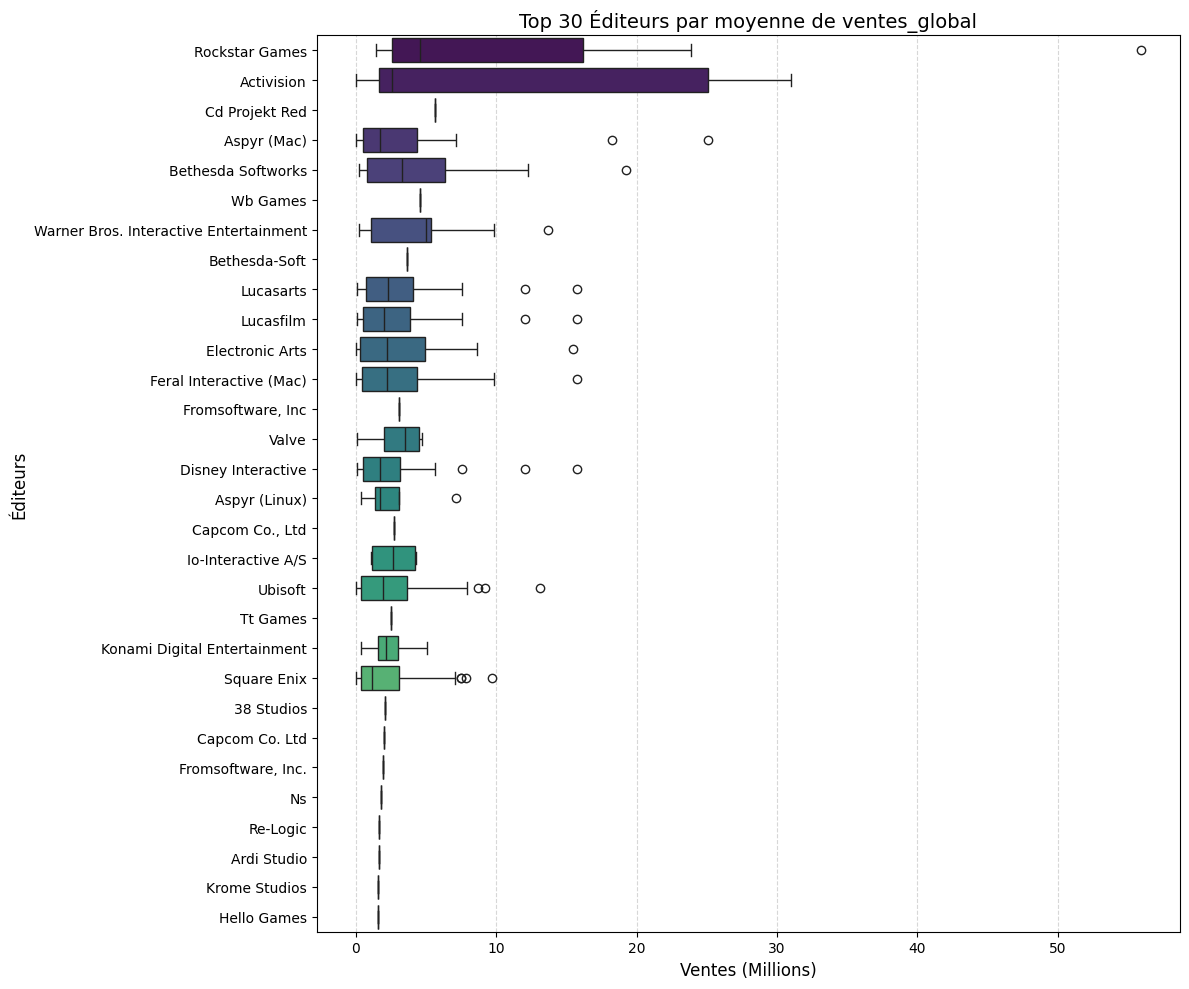

,editeur,ventes_global
0,Rockstar Games,55.92
1,Rockstar Games,23.86
2,Rockstar Games,16.19
3,Activision,31.03
4,Activision,29.72
...,...,...
713,Square Enix,0.02
726,Electronic Arts,0.02
742,Electronic Arts,0.02
761,Aspyr (Mac),0.01


In [32]:
plot_boxplot_editeur_top30('ventes_global', label_x="Ventes (Millions)", label_y="Éditeurs")

## Top 30 des Editeurs par moyenne des Ventes en Amérique du Nord

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='editeur', x=numeric_col, order=top_30, palette='viridis')


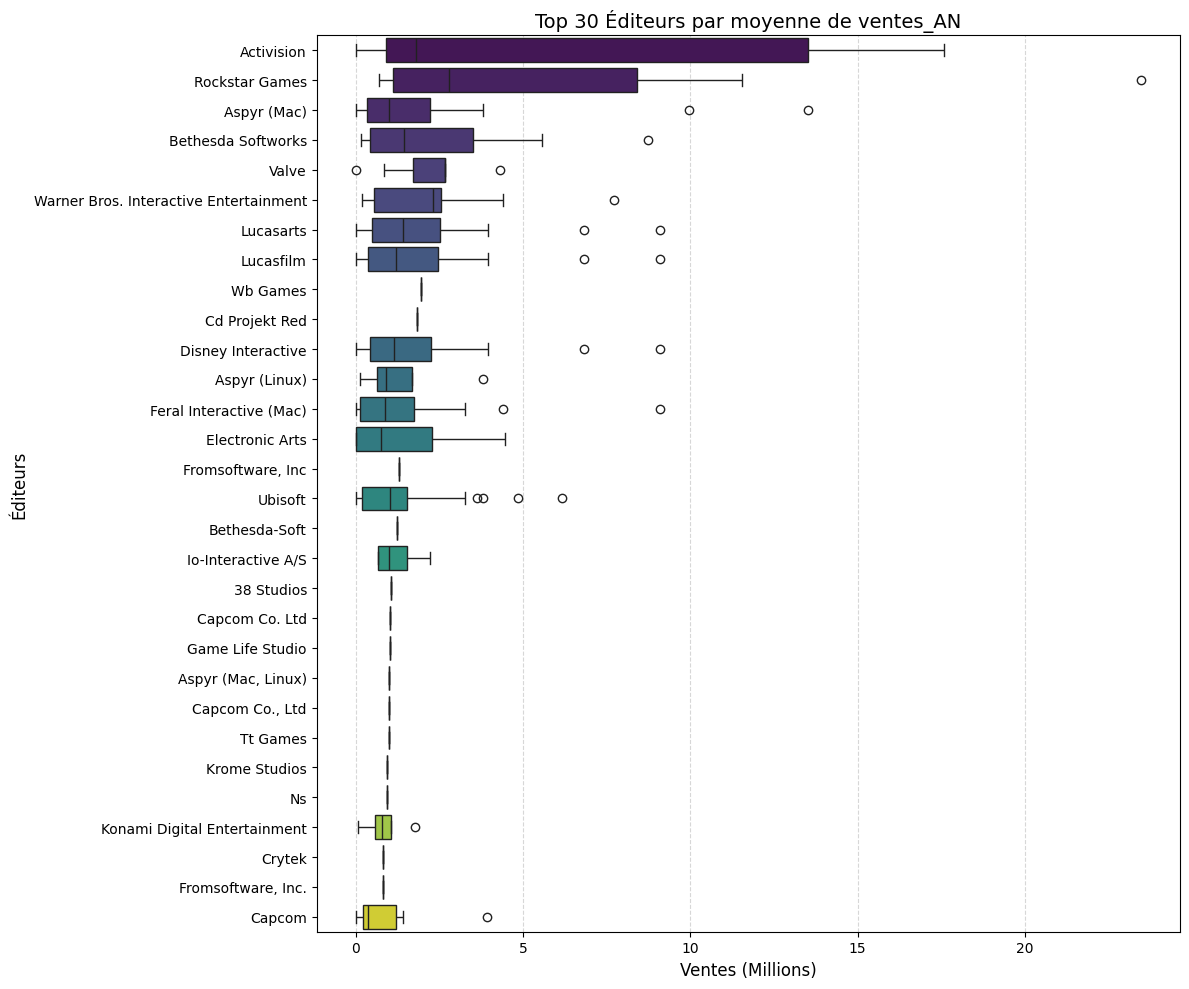

,editeur,ventes_AN
0,Rockstar Games,23.46
1,Rockstar Games,10.77
2,Rockstar Games,8.41
3,Activision,17.59
4,Activision,14.08
...,...,...
662,Ubisoft,0.00
726,Electronic Arts,0.00
742,Electronic Arts,0.00
761,Aspyr (Mac),0.00


In [34]:
plot_boxplot_editeur_top30('ventes_AN', label_x="Ventes (Millions)", label_y="Éditeurs")

## Top 30 des Editeurs par moyenne des Ventes en Europe

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='editeur', x=numeric_col, order=top_30, palette='viridis')


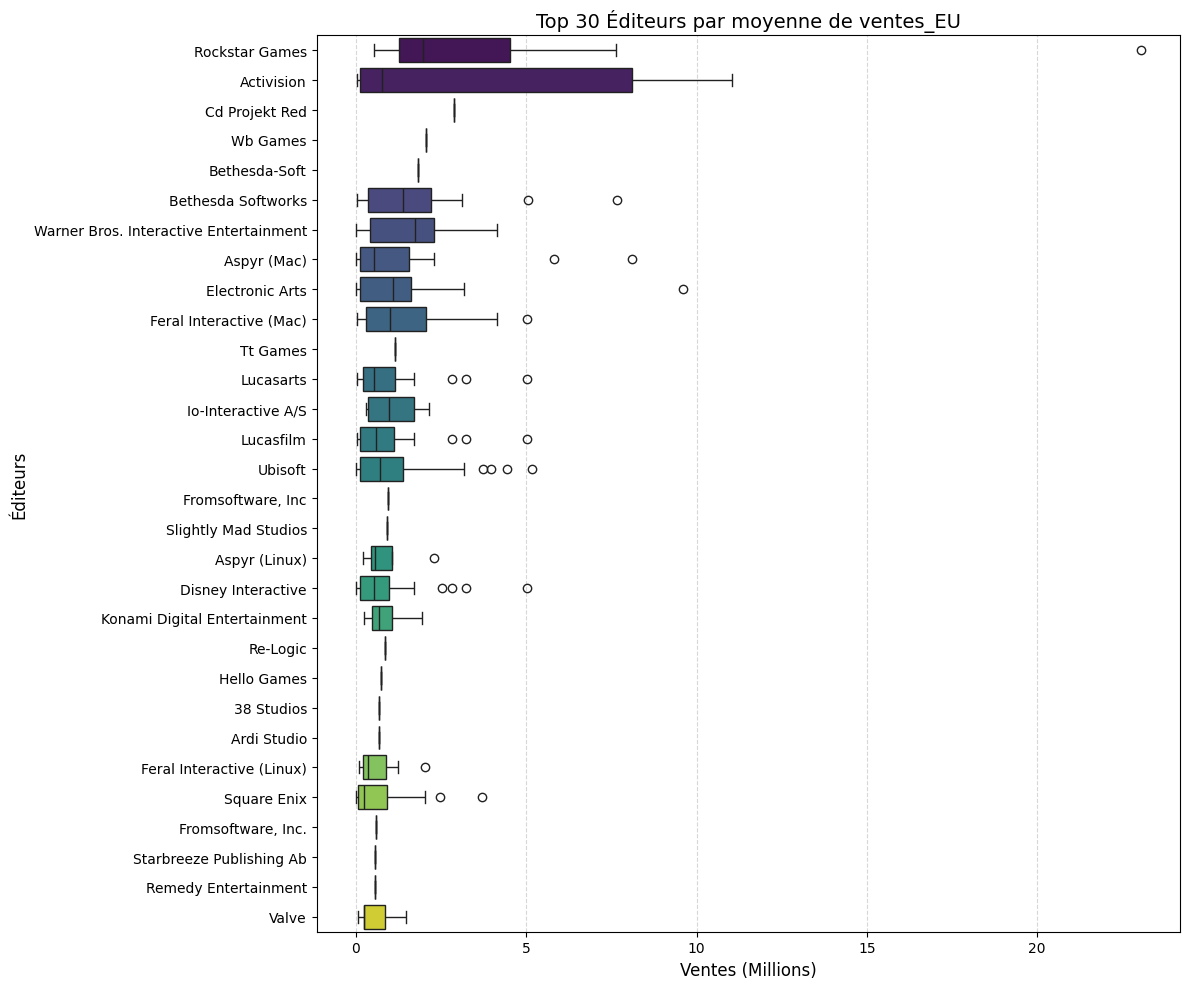

,editeur,ventes_EU
0,Rockstar Games,23.04
1,Rockstar Games,1.96
2,Rockstar Games,5.52
3,Activision,9.50
4,Activision,11.05
...,...,...
713,Square Enix,0.01
726,Electronic Arts,0.02
742,Electronic Arts,0.01
761,Aspyr (Mac),0.01


In [35]:
plot_boxplot_editeur_top30('ventes_EU', label_x="Ventes (Millions)", label_y="Éditeurs")

## Top 30 des Editeurs par moyenne des Ventes au Japon

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='editeur', x=numeric_col, order=top_30, palette='viridis')


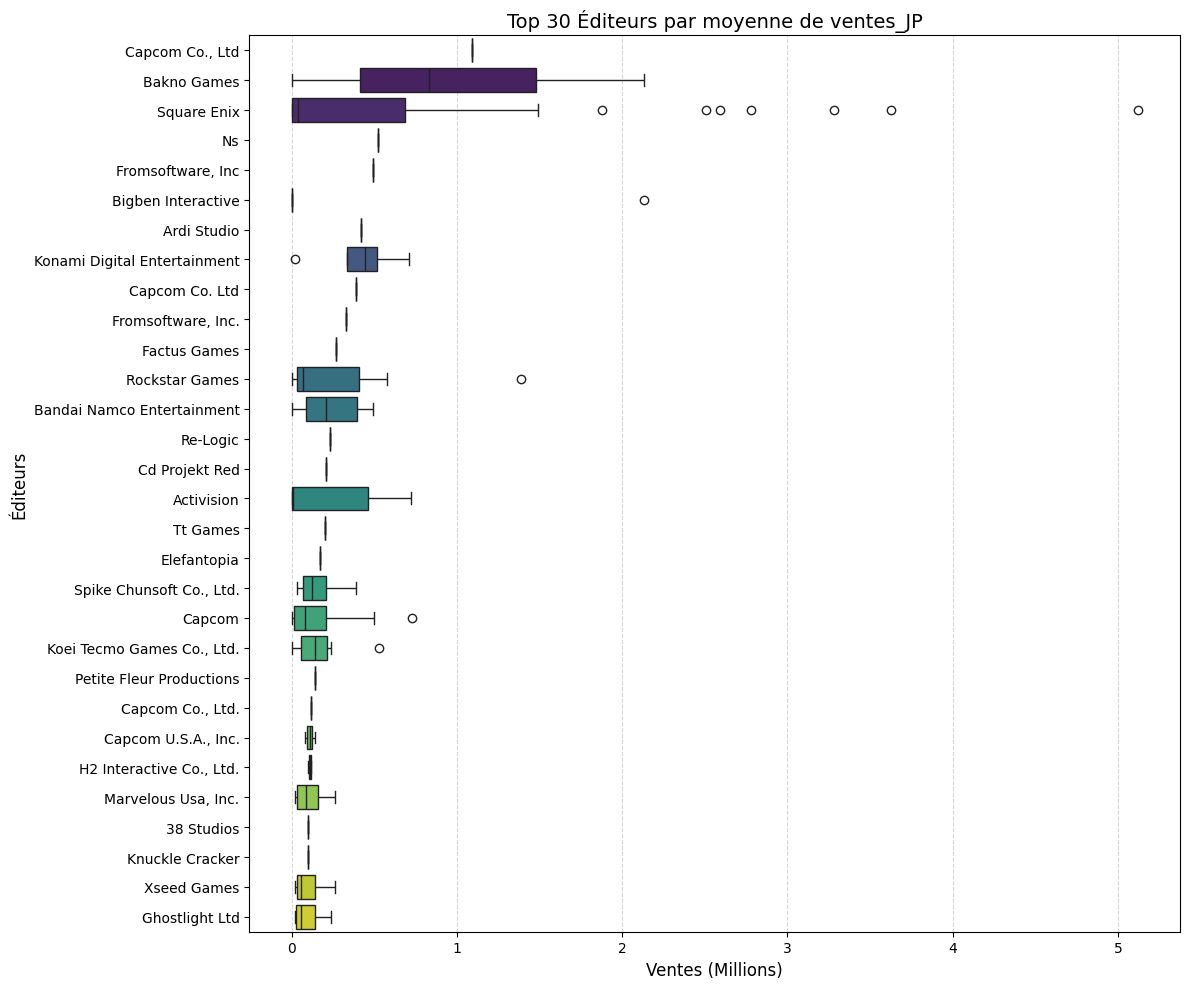

,editeur,ventes_JP
0,Rockstar Games,1.39
1,Rockstar Games,0.41
2,Rockstar Games,0.47
3,Activision,0.59
4,Activision,0.72
...,...,...
645,Activision,0.00
695,Square Enix,0.00
702,Ghostlight Ltd,0.02
713,Square Enix,0.00


In [37]:
plot_boxplot_editeur_top30('ventes_JP', label_x="Ventes (Millions)", label_y="Éditeurs")

## Top 30 des Editeurs par moyenne des Autres Ventes

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='editeur', x=numeric_col, order=top_30, palette='viridis')


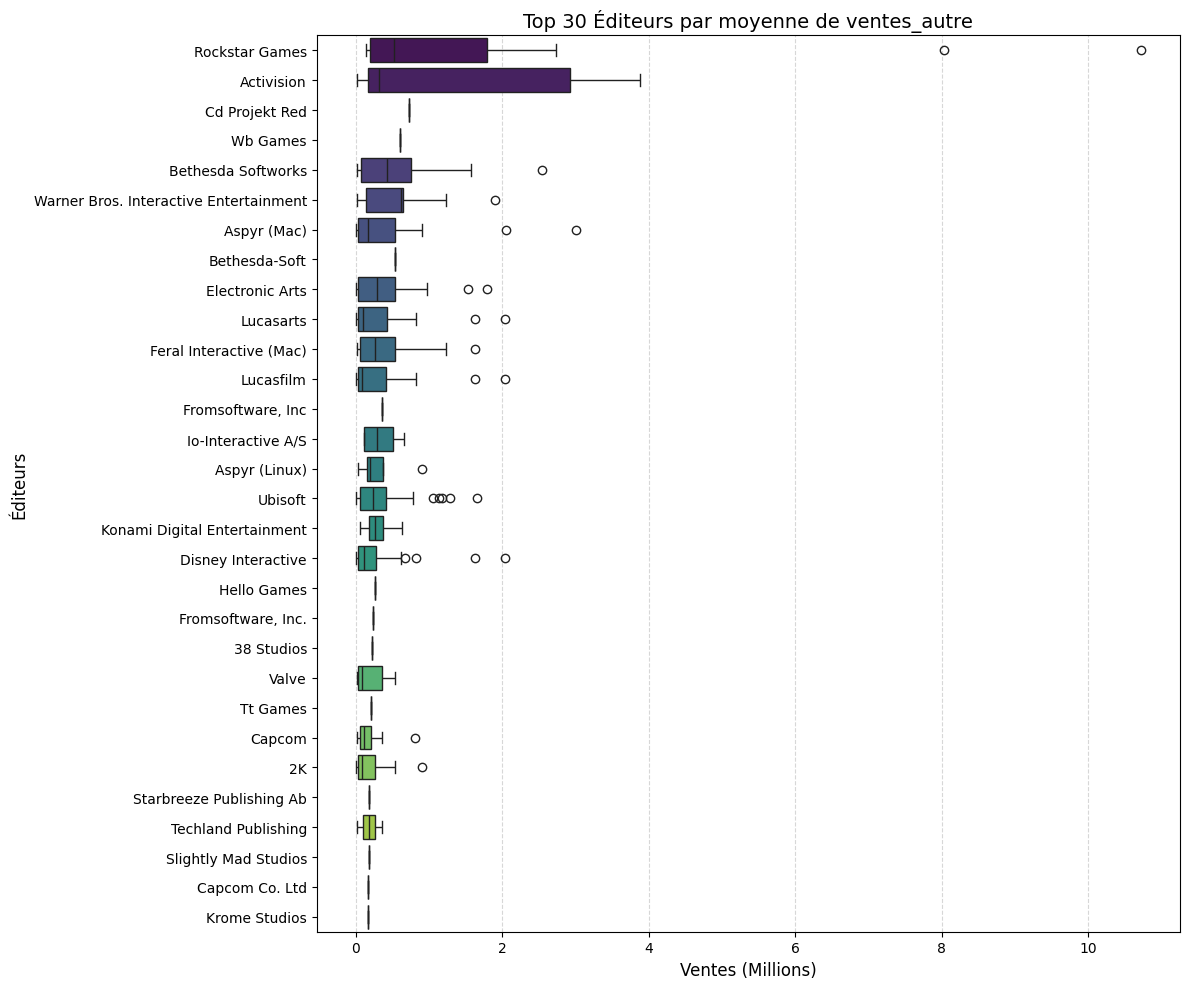

,editeur,ventes_autre
0,Rockstar Games,8.03
1,Rockstar Games,10.72
2,Rockstar Games,1.79
3,Activision,3.36
4,Activision,3.88
...,...,...
662,Ubisoft,0.00
726,Electronic Arts,0.00
742,Electronic Arts,0.00
761,Aspyr (Mac),0.00


In [39]:
plot_boxplot_editeur_top30('ventes_autre', label_x="Ventes (Millions)", label_y="Éditeurs")

## Top 30 des Editeurs par moyenne de prix

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\2285894933.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='editeur', x=numeric_col, order=top_30, palette='viridis')


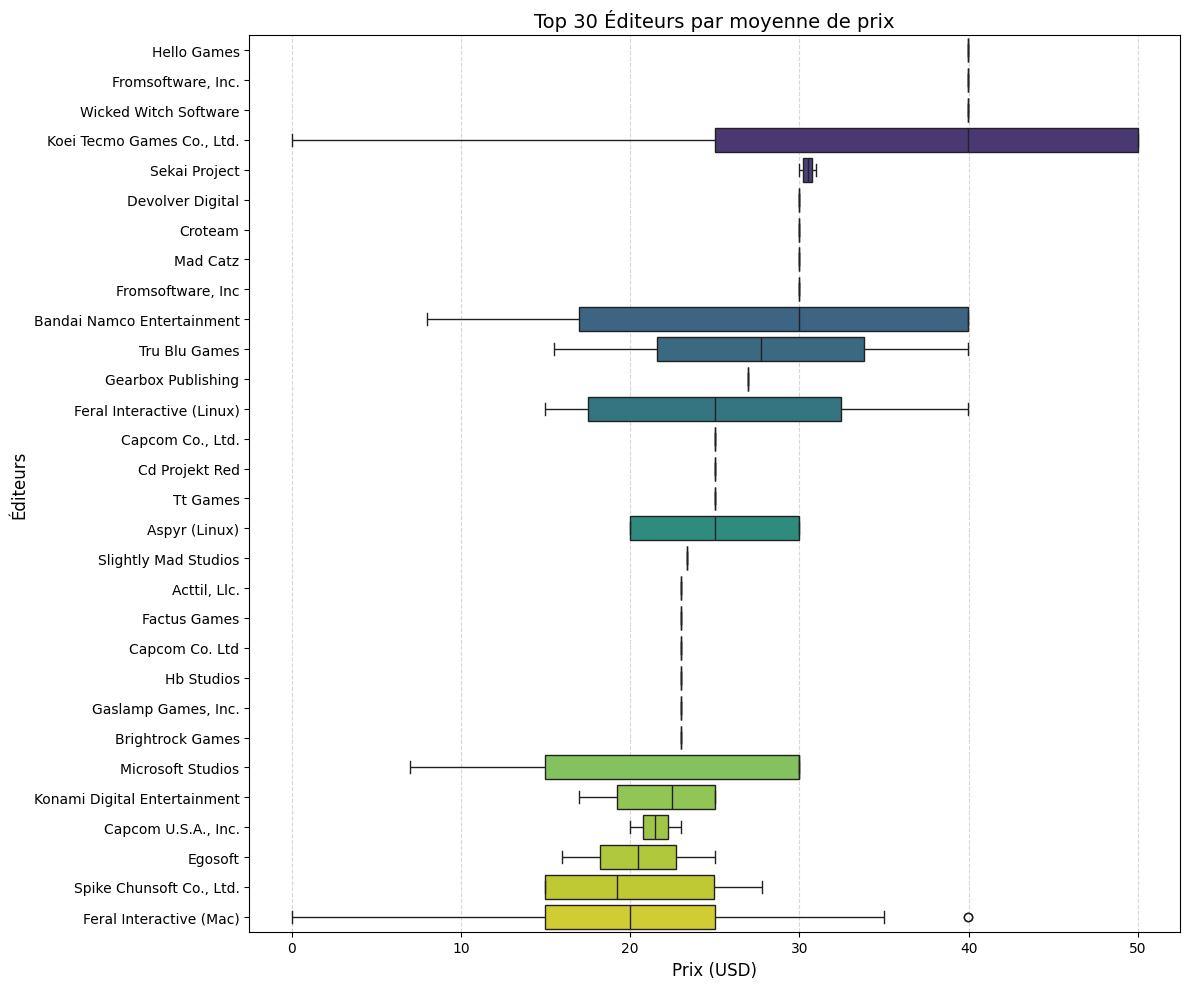

,editeur,prix
16,Feral Interactive (Mac),15.49
21,Feral Interactive (Mac),14.99
21,Feral Interactive (Linux),14.99
32,Cd Projekt Red,24.99
41,Konami Digital Entertainment,24.99
...,...,...
732,Devolver Digital,29.99
732,Croteam,29.99
761,Gearbox Publishing,26.99
764,Brightrock Games,22.99


In [41]:
plot_boxplot_editeur_top30('prix', label_x="Prix (USD)", label_y="Éditeurs")

## Fonction pour l'analyse des développeura et une variable quantitative

In [49]:
def plot_boxplot_dev_top30(numeric_col, label_x="Ventes", label_y="Développeur"):
    connect = getBDD()
    if not connect: return

    sql = f"SELECT developpeur.developpeur, jeux.{numeric_col} FROM jeux JOIN developpeur ON jeux.id_jeu = developpeur.id_jeu"
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

    df['developpeur'] = df['developpeur'].astype(str).str.strip()
    
    df['developpeur'] = df['developpeur'].str.split(';')
    df = df.explode('developpeur')

    df['developpeur'] = df['developpeur'].str.strip()
    df['developpeur'] = df['developpeur'].str.title() 

    parent_companies = [
        'Ubisoft', 'Nintendo', 'Sony', 'Electronic Arts', 
        'Square Enix', 'Sega', 'Capcom', 'Bandai Namco', 'Konami', 'Rockstar'
    ]
    
    for parent in parent_companies:
        mask = df['developpeur'].str.contains(parent, case=False, na=False)
        df.loc[mask, 'developpeur'] = parent
        
    mask_ea = df['developpeur'].str.startswith('Ea ')
    df.loc[mask_ea, 'developpeur'] = 'Electronic Arts'

    df = df[df['developpeur'] != '']
    df = df[df['developpeur'].str.lower() != 'nan']
    df = df.dropna(subset=[numeric_col, 'developpeur'])

    top_30= df.groupby('developpeur')[numeric_col].mean().sort_values(ascending=False).head(30).index
    df_top30 = df[df['developpeur'].isin(top_30)]

    plt.figure(figsize=(12, 10))
    sns.boxplot(data=df_top30, y='developpeur', x=numeric_col, order=top_30, palette='viridis')

    plt.title(f'Top 30 Développeurs par moyenne de {numeric_col}', fontsize=14)
    plt.xlabel(label_x, fontsize=12)
    plt.ylabel(label_y, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    return df_top30

## Top 30 des Développeurs par moyenne de Ventes globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='developpeur', x=numeric_col, order=top_30, palette='viridis')


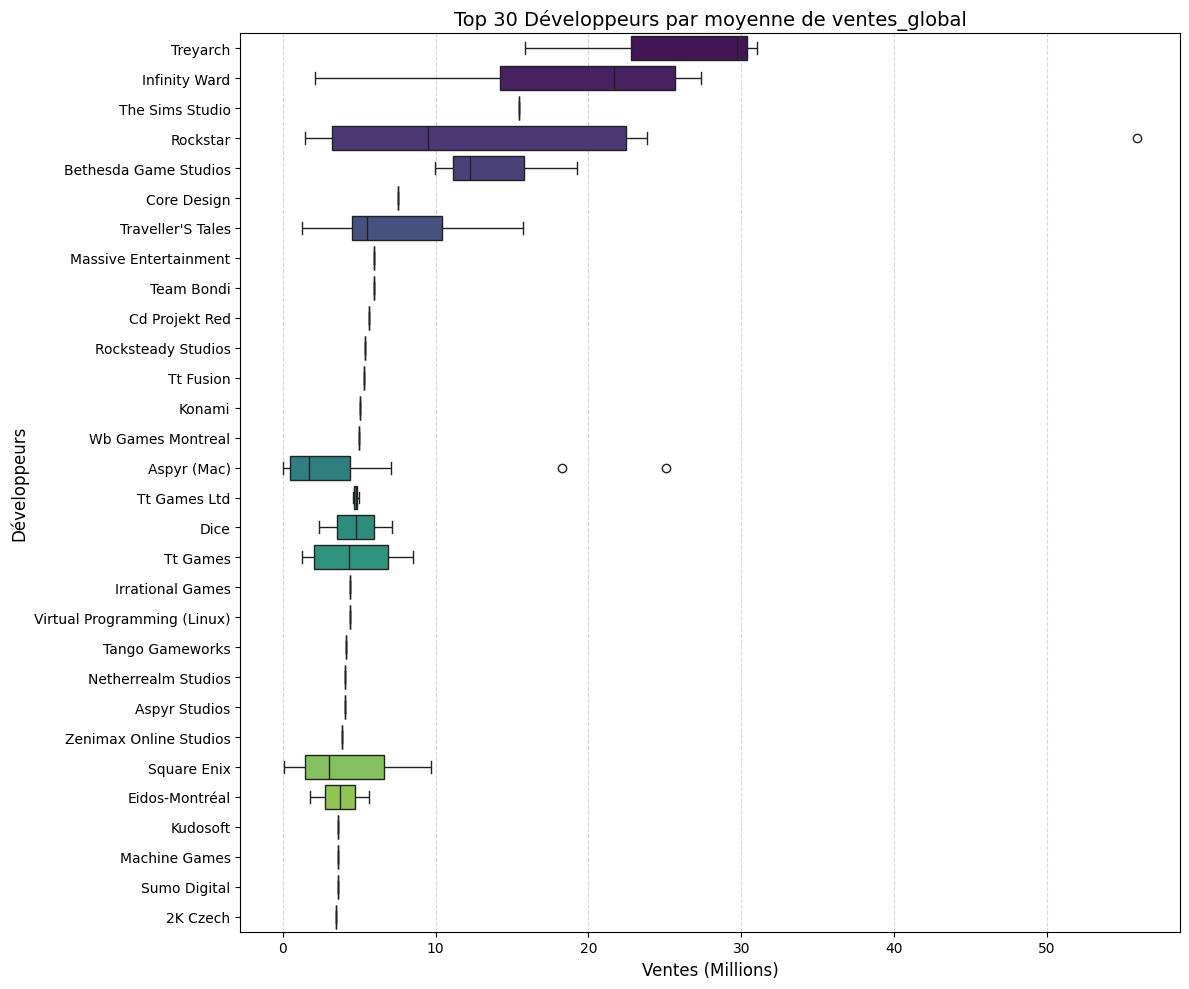

,developpeur,ventes_global
0,Rockstar,55.92
1,Rockstar,23.86
2,Rockstar,16.19
3,Treyarch,31.03
4,Treyarch,29.72
...,...,...
305,Aspyr (Mac),0.37
330,Aspyr (Mac),0.54
542,Square Enix,0.08
551,Aspyr (Mac),0.07


In [51]:
plot_boxplot_dev_top30('ventes_global', label_x="Ventes (Millions)", label_y="Développeurs")

## Top 30 des Développeurs par moyenne de Ventes en Amérique du Nord

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='developpeur', x=numeric_col, order=top_30, palette='viridis')


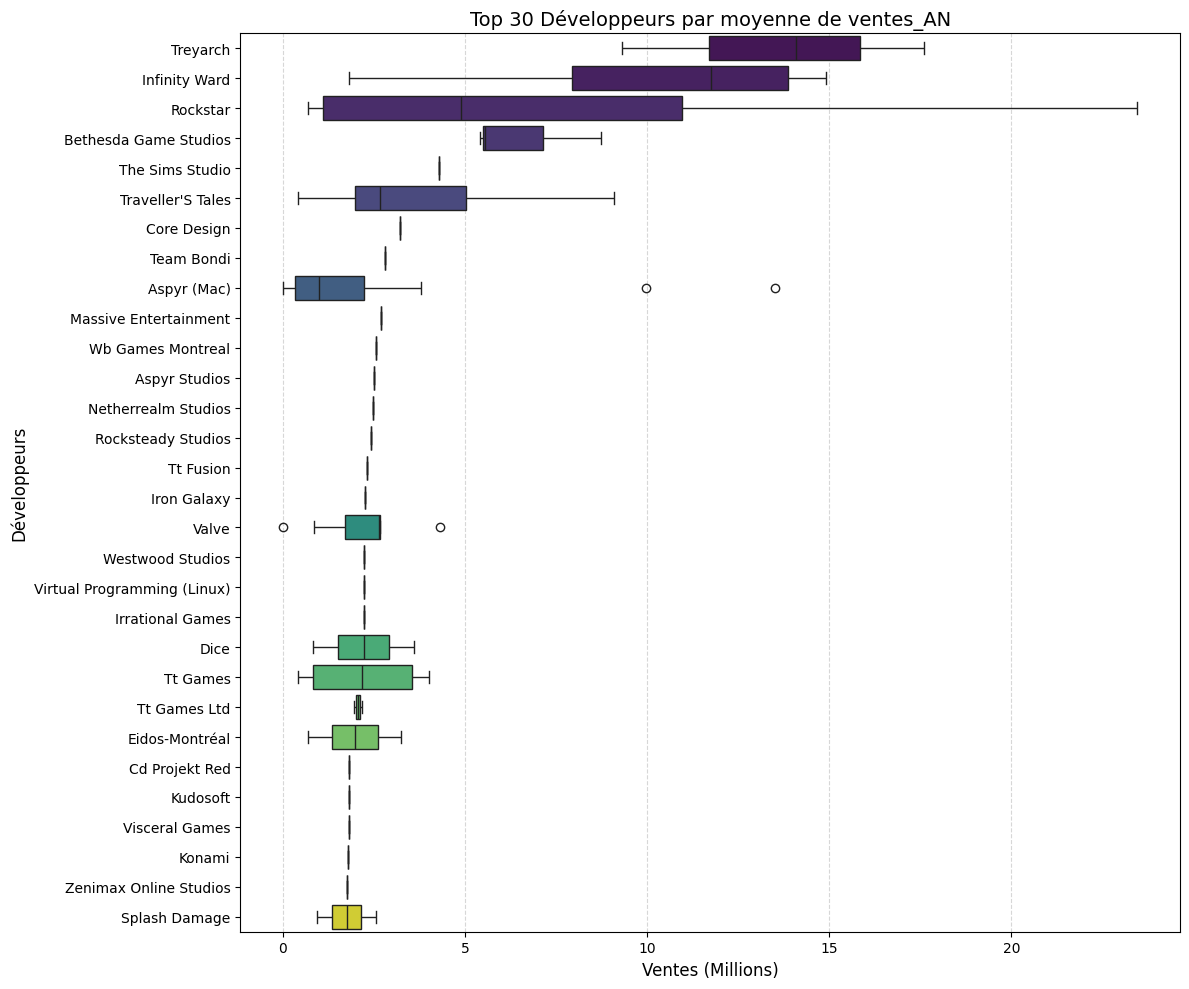

,developpeur,ventes_AN
0,Rockstar,23.46
1,Rockstar,10.77
2,Rockstar,8.41
3,Treyarch,17.59
4,Treyarch,14.08
...,...,...
305,Aspyr (Mac),0.11
330,Aspyr (Mac),0.41
528,Valve,0.00
551,Aspyr (Mac),0.00


In [52]:
plot_boxplot_dev_top30('ventes_AN', label_x="Ventes (Millions)", label_y="Développeurs")

## Top 30 des Développeurs par moyenne de Ventes en Europe

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='developpeur', x=numeric_col, order=top_30, palette='viridis')


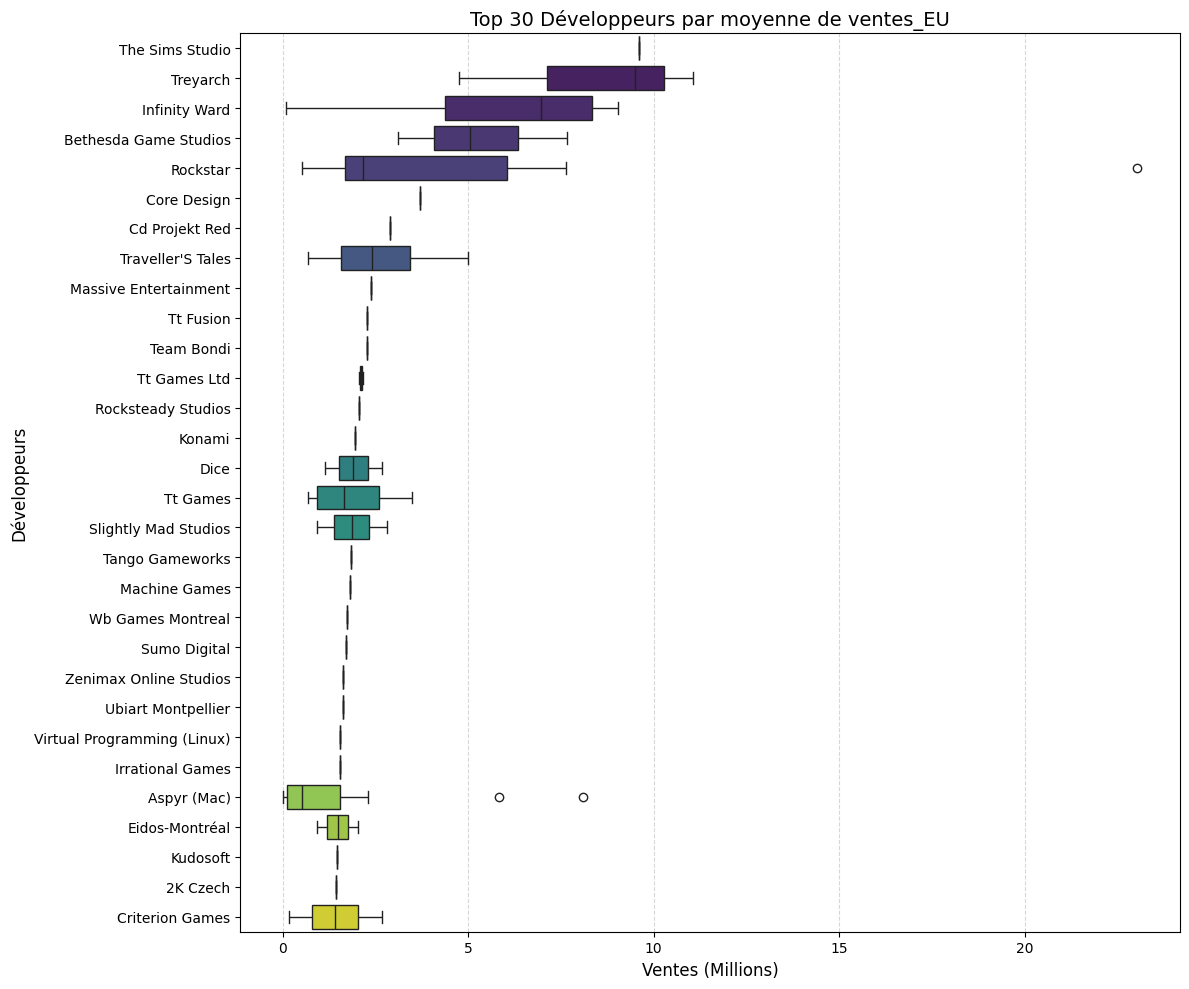

,developpeur,ventes_EU
0,Rockstar,23.04
1,Rockstar,1.96
2,Rockstar,5.52
3,Treyarch,9.50
4,Treyarch,11.05
...,...,...
305,Aspyr (Mac),0.22
330,Aspyr (Mac),0.12
511,Criterion Games,0.17
551,Aspyr (Mac),0.06


In [53]:
plot_boxplot_dev_top30('ventes_EU', label_x="Ventes (Millions)", label_y="Développeurs")

## Top 30 des Développeurs par moyenne de Ventes au Japon

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='developpeur', x=numeric_col, order=top_30, palette='viridis')


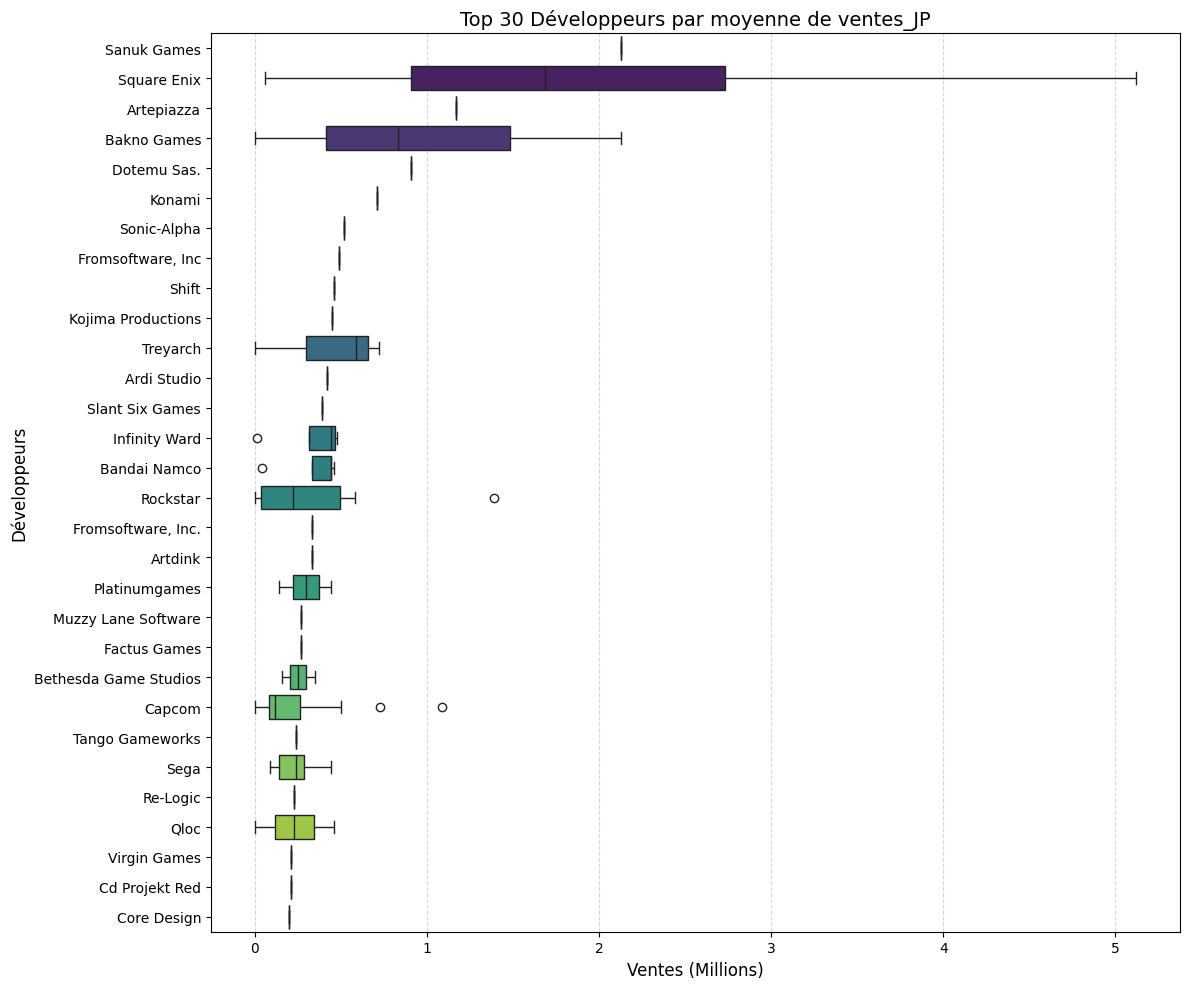

,developpeur,ventes_JP
0,Rockstar,1.39
1,Rockstar,0.41
2,Rockstar,0.47
3,Treyarch,0.59
4,Treyarch,0.72
...,...,...
473,Sega,0.12
512,Capcom,0.00
516,Bakno Games,0.00
542,Square Enix,0.08


In [54]:
plot_boxplot_dev_top30('ventes_JP', label_x="Ventes (Millions)", label_y="Développeurs")

## Top 30 des Développeurs par moyenne des Autres Ventes

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='developpeur', x=numeric_col, order=top_30, palette='viridis')


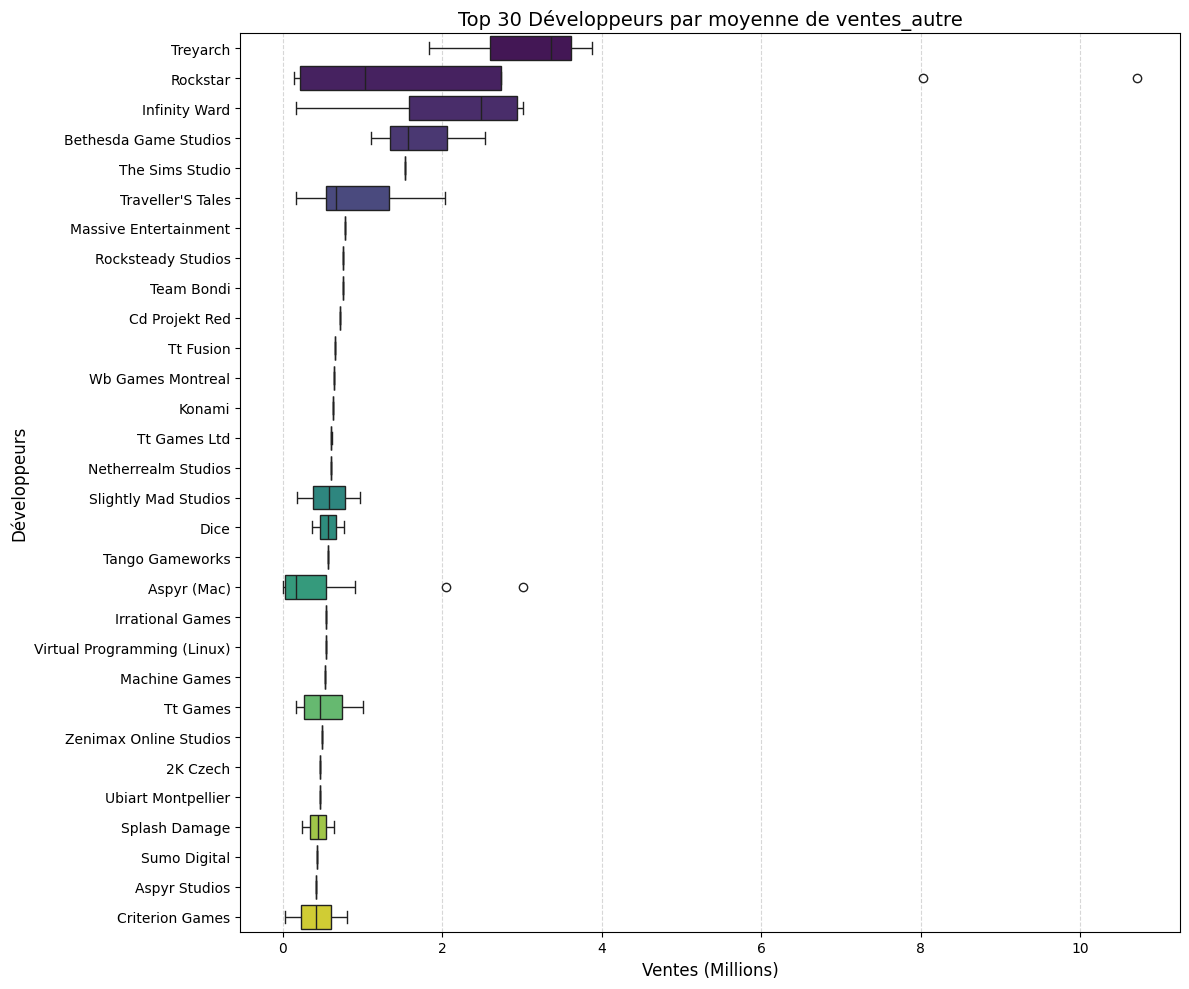

,developpeur,ventes_autre
0,Rockstar,8.03
1,Rockstar,10.72
2,Rockstar,1.79
3,Treyarch,3.36
4,Treyarch,3.88
...,...,...
305,Aspyr (Mac),0.03
330,Aspyr (Mac),0.02
511,Criterion Games,0.03
551,Aspyr (Mac),0.01


In [55]:
plot_boxplot_dev_top30('ventes_autre', label_x="Ventes (Millions)", label_y="Développeurs")

## Top 30 des Développeurs par moyenne de Ventes globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\481208484.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top30, y='developpeur', x=numeric_col, order=top_30, palette='viridis')


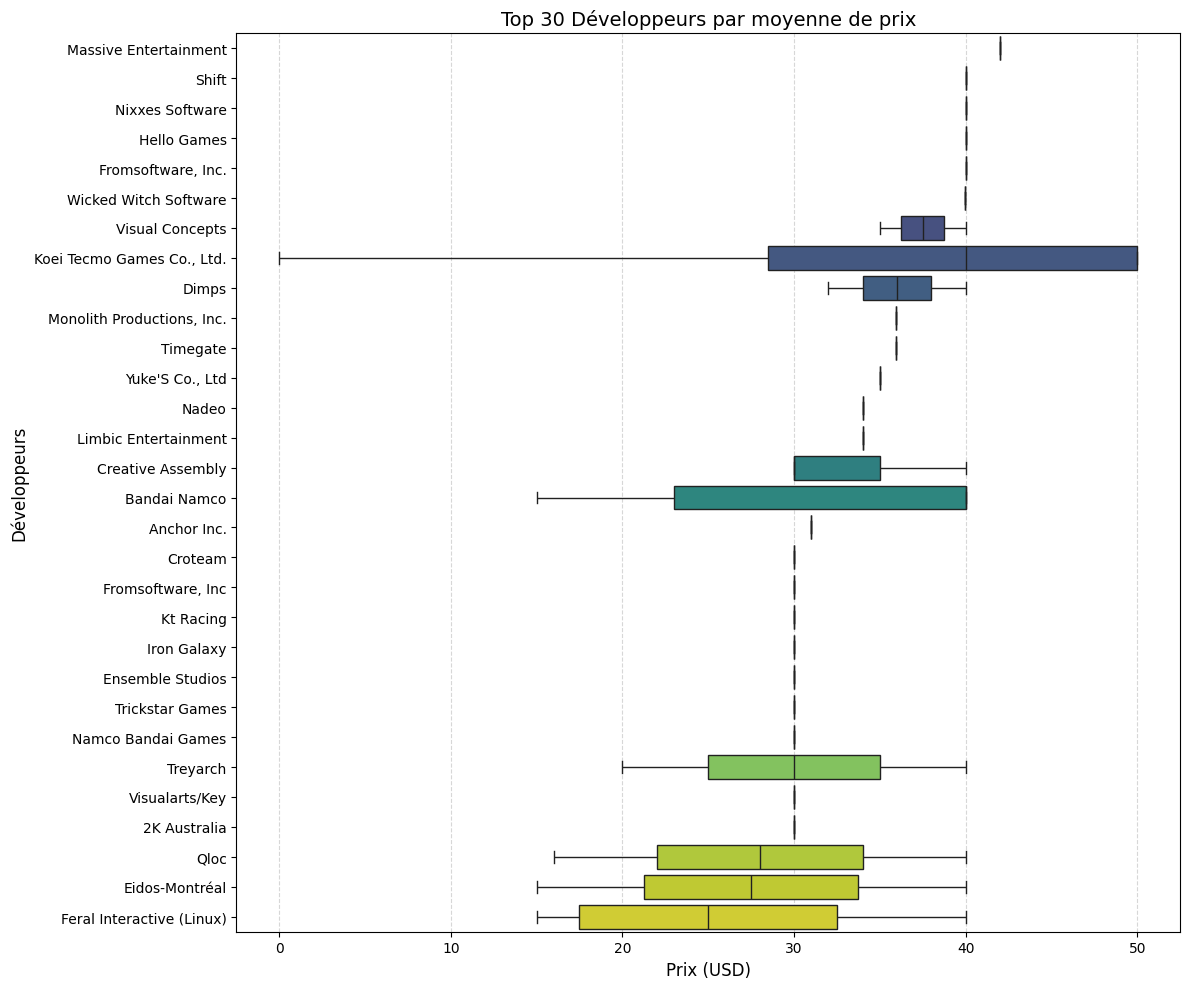

,developpeur,prix
3,Treyarch,29.99
4,Treyarch,39.99
14,Treyarch,19.99
21,Eidos-Montréal,14.99
21,Feral Interactive (Linux),14.99
...,...,...
621,Wicked Witch Software,39.95
640,Visualarts/Key,29.99
653,Bandai Namco,22.99
732,Croteam,29.99


In [56]:
plot_boxplot_dev_top30('prix', label_x="Prix (USD)", label_y="Développeurs")

## Fonction pour l'analyse des catégories et une variable quantitative

In [62]:
def plot_boxplot_categorie(numeric_col, label_x="Catégorie", label_y="Valeur"):
    connect = getBDD()
    if not connect: return

    sql = f"""
        SELECT categorie.categorie, jeux.{numeric_col} 
        FROM jeux 
        JOIN a_categorie ON jeux.id_jeu = a_categorie.id_jeu
        JOIN categorie ON a_categorie.id_cat = categorie.id_cat
    """
    
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

    df['categorie'] = df['categorie'].astype(str).str.strip()
    df = df[df['categorie'] != '']
    df = df[df['categorie'].str.lower() != 'nan']
    
    df = df.dropna(subset=[numeric_col, 'categorie'])

    upper_limit = df[numeric_col].quantile(0.90)
    df = df[df[numeric_col] <= upper_limit]

    counts = df['categorie'].value_counts()
    valid_categories = counts[counts >= 7].index
    df = df[df['categorie'].isin(valid_categories)]
    
    order = df.groupby('categorie')[numeric_col].median().sort_values(ascending=False).index

    plt.figure(figsize=(14, 8))
    
    sns.boxplot(data=df, x='categorie', y=numeric_col, order=order, palette='viridis')

    plt.title(f'Distribution de {numeric_col} par Catégorie (Top 10% outliers supprimés)', fontsize=15)
    plt.xlabel(label_x, fontsize=12, fontweight='bold')
    plt.ylabel(label_y, fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    return df

## Catégories et Ventes Globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categorie', y=numeric_col, order=order, palette='viridis')


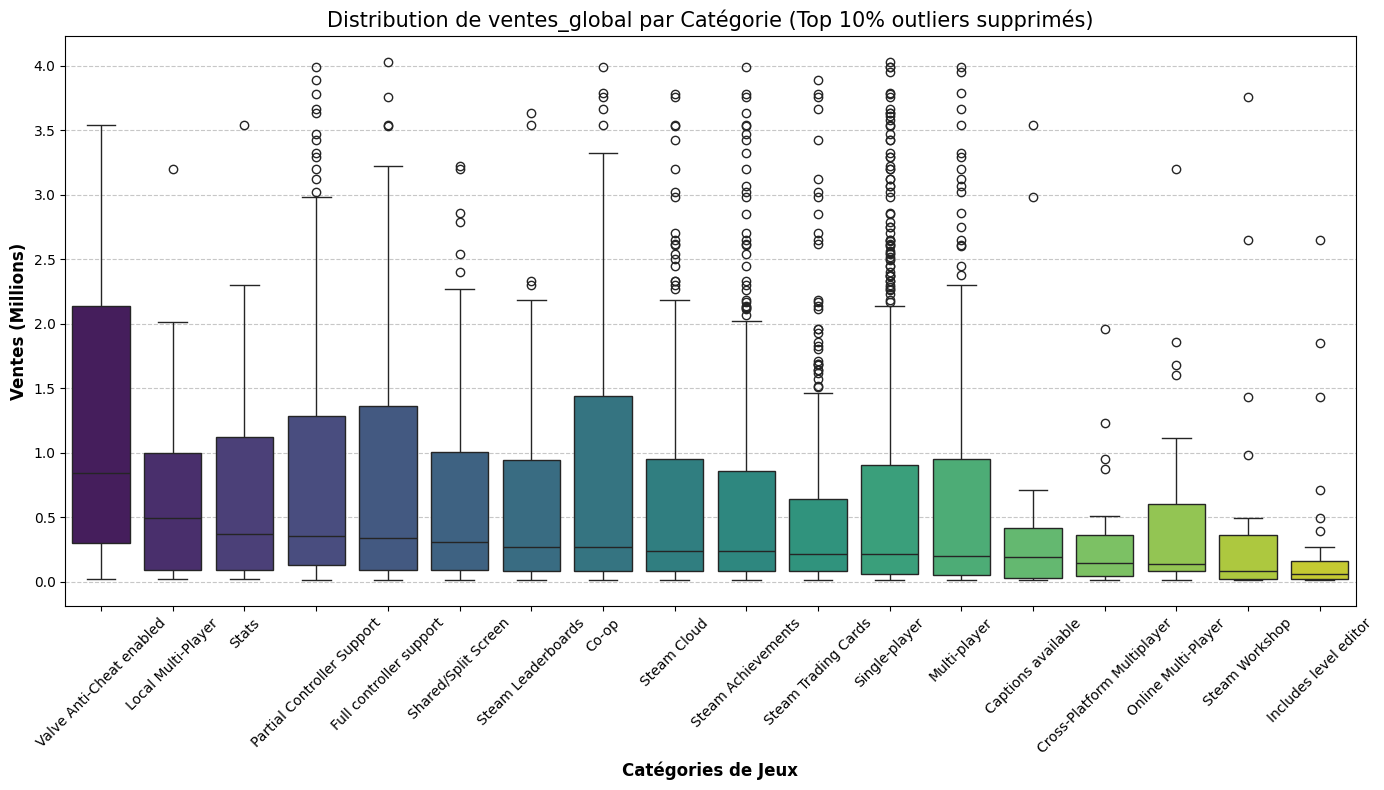

,categorie,ventes_global
145,Steam Leaderboards,3.54
146,Stats,3.54
147,Valve Anti-Cheat enabled,3.54
148,Steam Cloud,3.54
149,Captions available,3.54
...,...,...
2941,Steam Cloud,0.01
2942,Steam Trading Cards,0.01
2943,Full controller support,0.01
2944,Steam Achievements,0.01


In [71]:
plot_boxplot_categorie('ventes_global', "Catégories de Jeux", "Ventes (Millions)")

## Catégories et Ventes en Amérique du Nord

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categorie', y=numeric_col, order=order, palette='viridis')


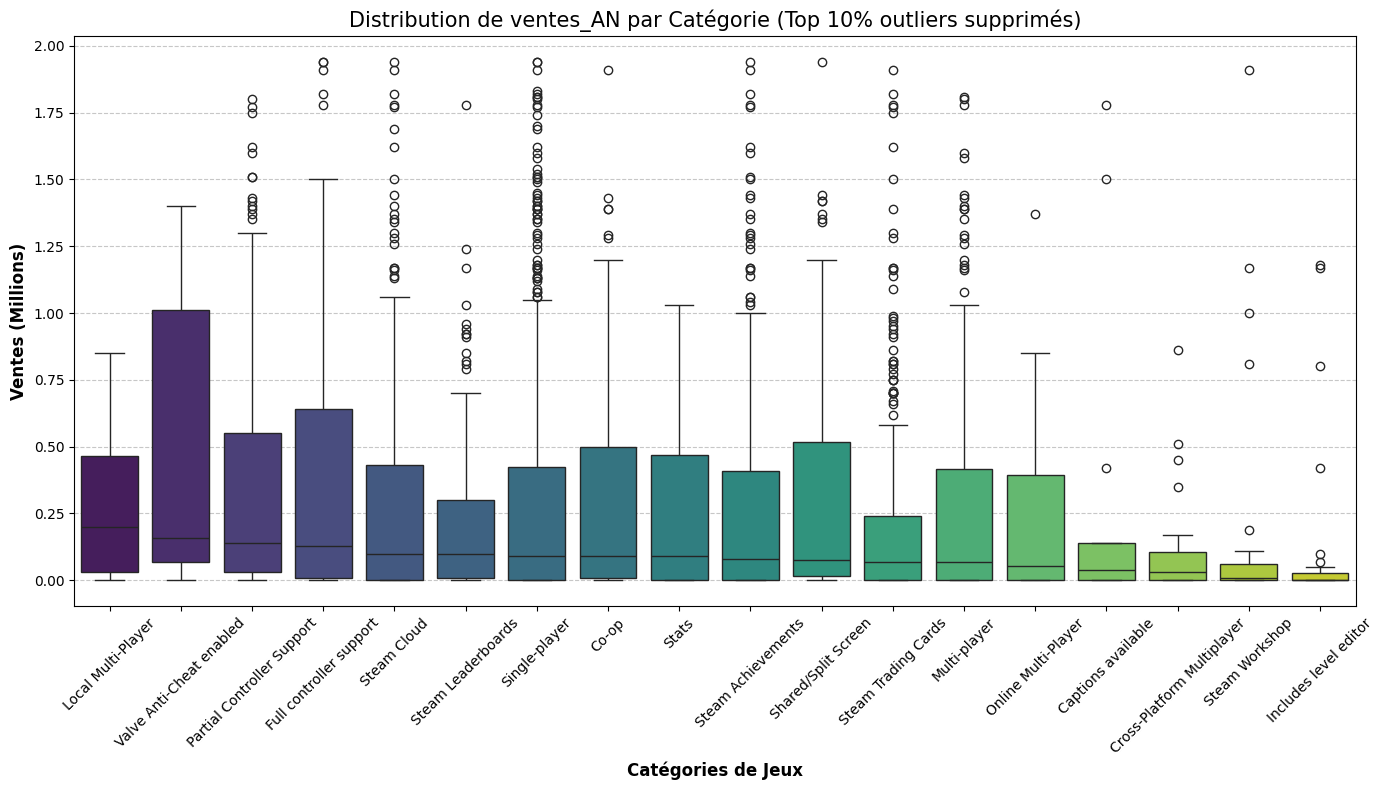

,categorie,ventes_AN
72,Steam Cloud,1.62
73,Partial Controller Support,1.62
74,Steam Trading Cards,1.62
75,Steam Achievements,1.62
76,Single-player,1.62
...,...,...
2941,Steam Cloud,0.00
2942,Steam Trading Cards,0.00
2943,Full controller support,0.00
2944,Steam Achievements,0.00


In [72]:
plot_boxplot_categorie('ventes_AN', "Catégories de Jeux", "Ventes (Millions)")

## Catégories et Ventes en Europe

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categorie', y=numeric_col, order=order, palette='viridis')


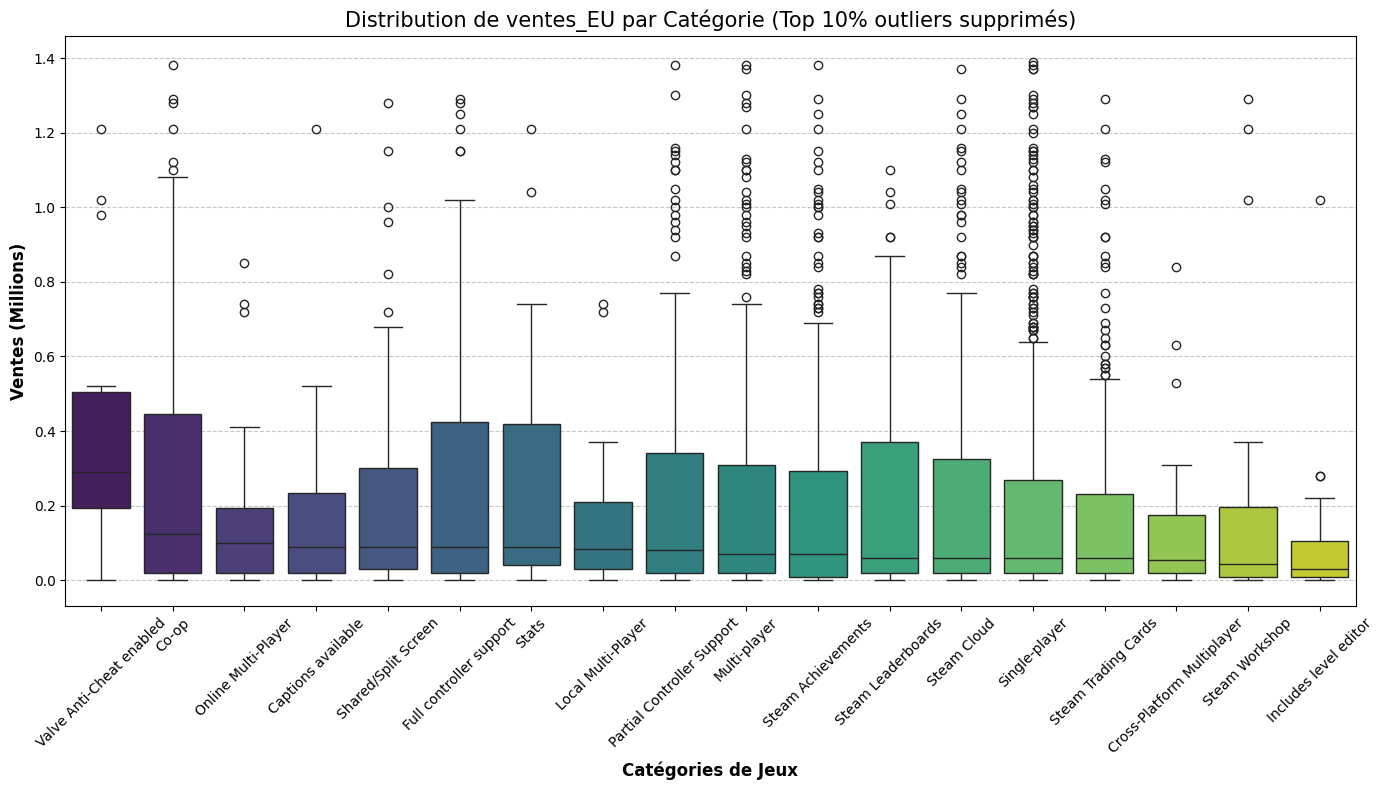

,categorie,ventes_EU
72,Steam Cloud,0.77
73,Partial Controller Support,0.77
74,Steam Trading Cards,0.77
75,Steam Achievements,0.77
76,Single-player,0.77
...,...,...
2941,Steam Cloud,0.01
2942,Steam Trading Cards,0.01
2943,Full controller support,0.01
2944,Steam Achievements,0.01


In [73]:
plot_boxplot_categorie('ventes_EU', "Catégories de Jeux", "Ventes (Millions)")

## Catégories et Ventes au Japon

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categorie', y=numeric_col, order=order, palette='viridis')


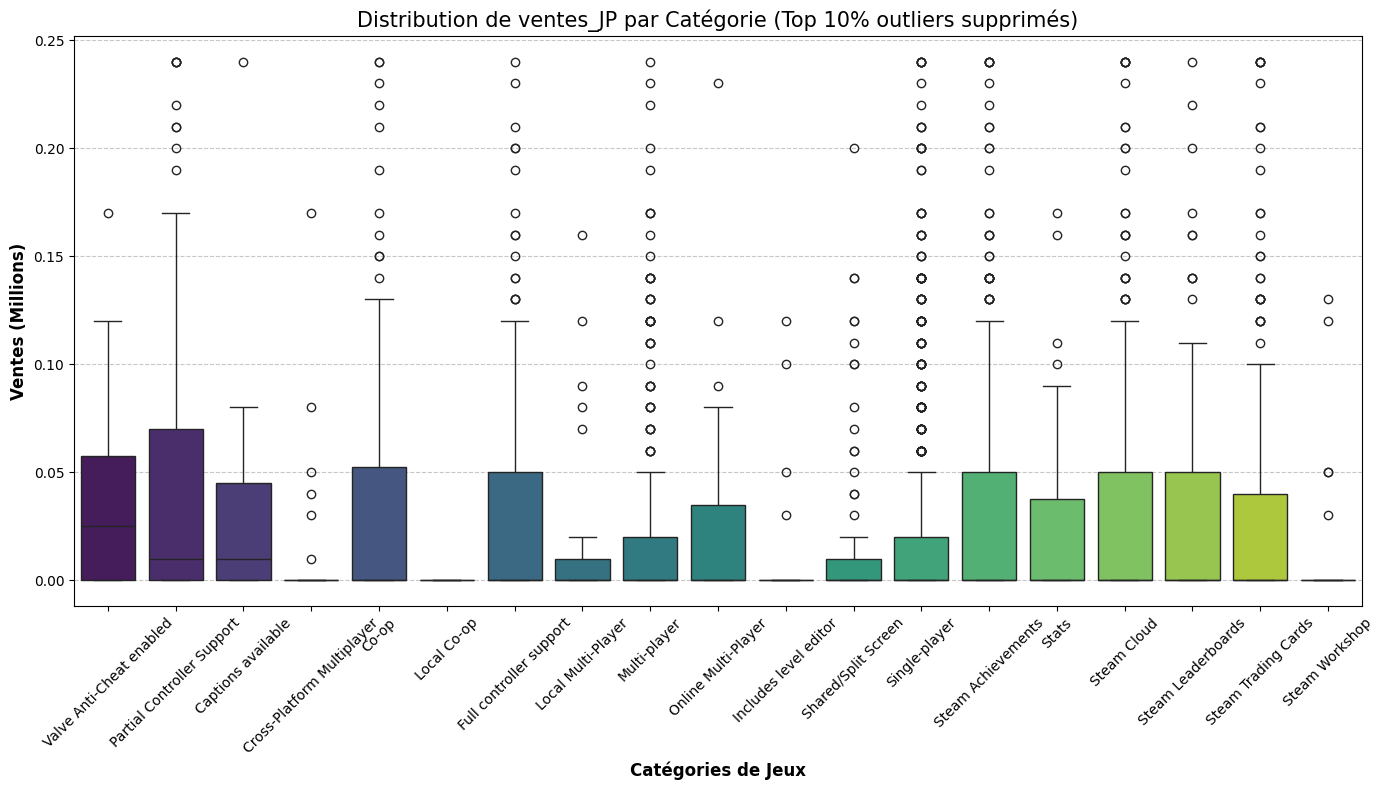

,categorie,ventes_JP
51,Single-player,0.05
56,Co-op,0.00
57,Multi-player,0.00
58,Single-player,0.00
63,Steam Cloud,0.00
...,...,...
2941,Steam Cloud,0.00
2942,Steam Trading Cards,0.00
2943,Full controller support,0.00
2944,Steam Achievements,0.00


In [74]:
plot_boxplot_categorie('ventes_JP', "Catégories de Jeux", "Ventes (Millions)")

## Catégories et Autres Ventes

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categorie', y=numeric_col, order=order, palette='viridis')


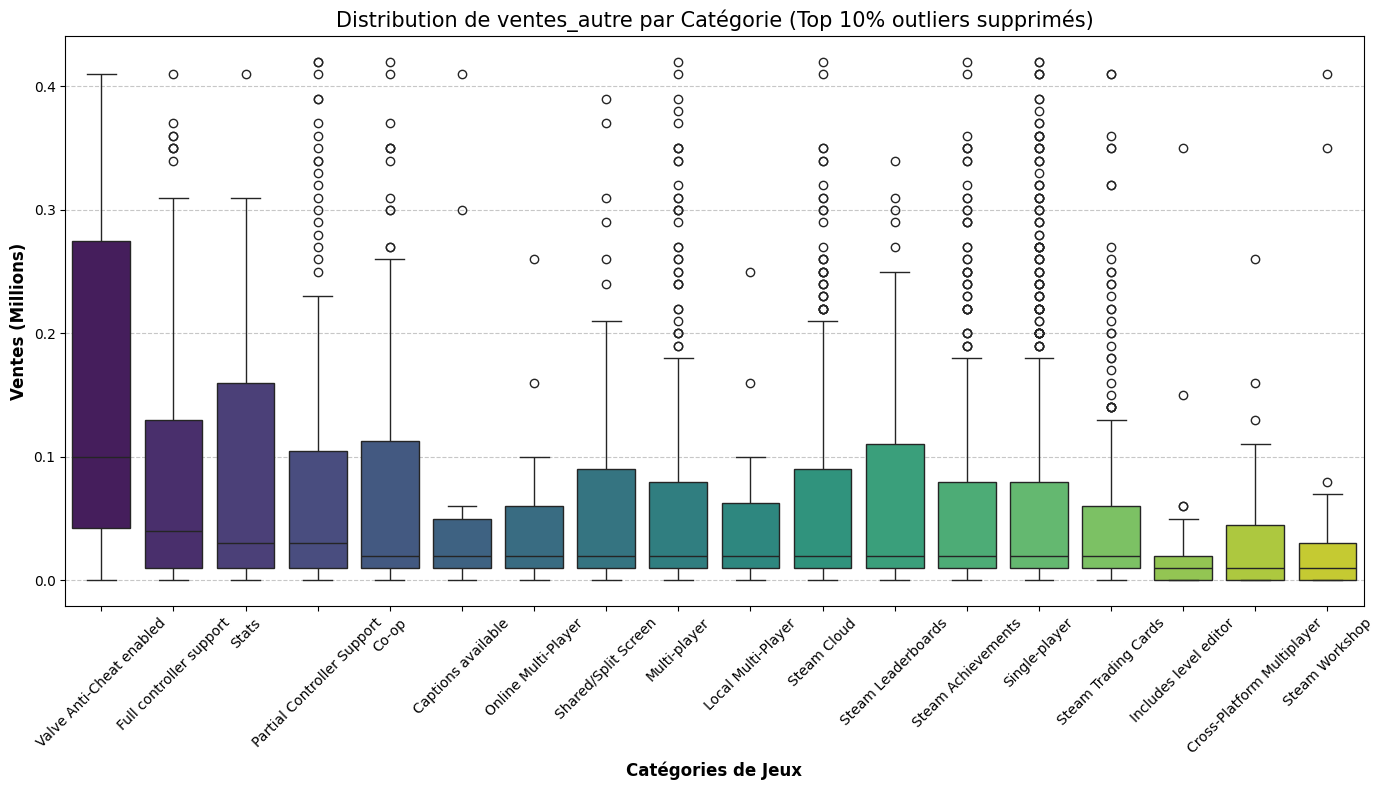

,categorie,ventes_autre
52,Steam Cloud,0.23
53,Partial Controller Support,0.23
54,Steam Achievements,0.23
55,Single-player,0.23
72,Steam Cloud,0.14
...,...,...
2941,Steam Cloud,0.00
2942,Steam Trading Cards,0.00
2943,Full controller support,0.00
2944,Steam Achievements,0.00


In [75]:
plot_boxplot_categorie('ventes_autre', "Catégories de Jeux", "Ventes (Millions)")

## Catégories et prix

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\183562811.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categorie', y=numeric_col, order=order, palette='viridis')


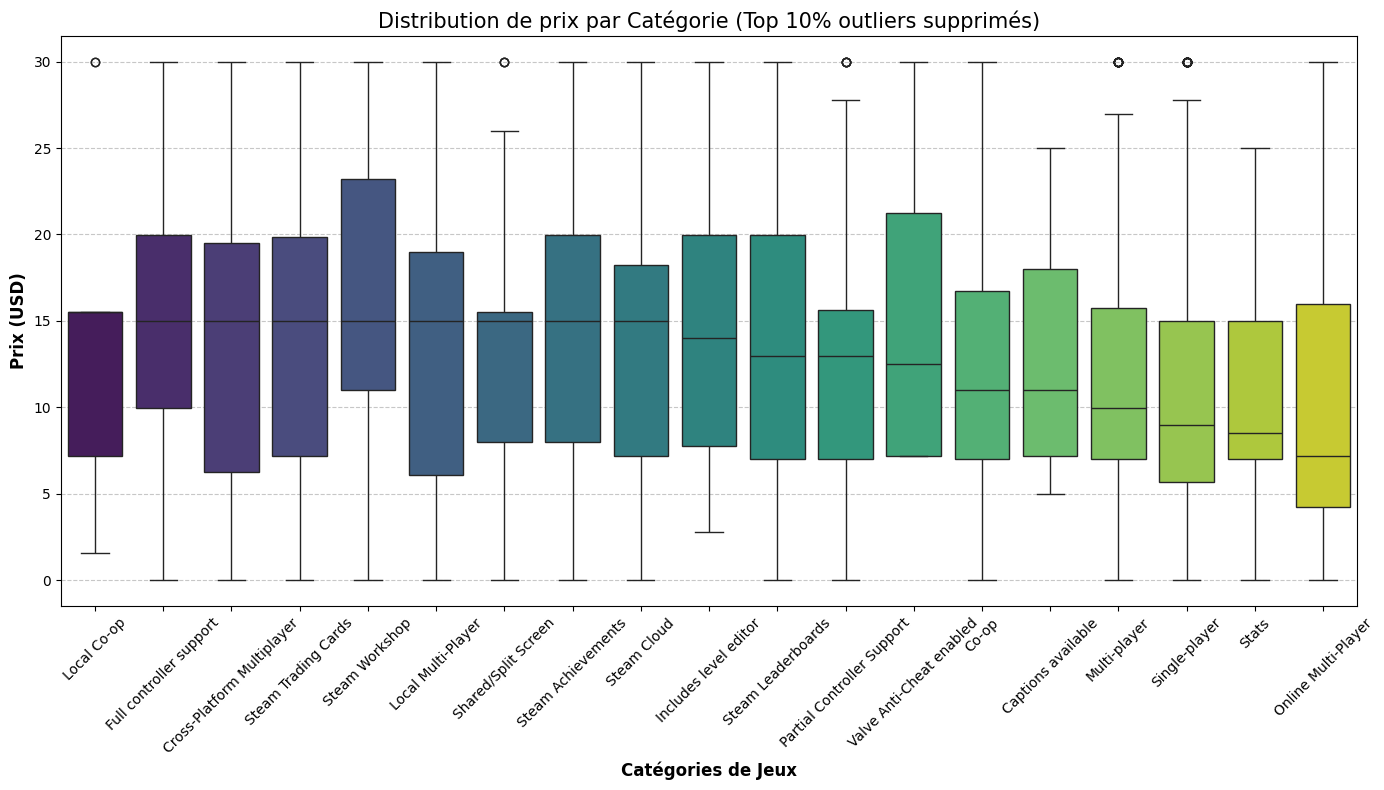

,categorie,prix
0,Full controller support,24.99
1,Steam Achievements,24.99
2,Multi-player,24.99
3,Single-player,24.99
4,Single-player,9.99
...,...,...
2941,Steam Cloud,6.99
2942,Steam Trading Cards,6.99
2943,Full controller support,6.99
2944,Steam Achievements,6.99


In [70]:
plot_boxplot_categorie('prix', "Catégories de Jeux", "Prix (USD)")

#### Fonction pour l'analyse des OS et une variable quantitative

In [77]:
def plot_boxplot_os(numeric_col, label_x="OS", label_y="Valeur"):
    connect = getBDD()
    if not connect: return

    sql = f"""
        SELECT os.os, jeux.{numeric_col} 
        FROM jeux 
        JOIN a_os ON jeux.id_jeu = a_os.id_jeu
        JOIN os ON a_os.id_os = os.id_os
    """
    
    df = pd.read_sql(sql, connect)
    connect.close()

    df[numeric_col] = df[numeric_col].astype(str).str.replace(',', '.')
    df[numeric_col] = pd.to_numeric(df[numeric_col], errors='coerce')

    df['os'] = df['os'].astype(str).str.strip()
    df = df[df['os'] != '']
    df = df[df['os'].str.lower() != 'nan']
    
    df = df.dropna(subset=[numeric_col, 'os'])

    upper_limit = df[numeric_col].quantile(0.90)
    df = df[df[numeric_col] <= upper_limit]

    counts = df['os'].value_counts()
    valid_os = counts[counts >= 7].index
    df = df[df['os'].isin(valid_os)]
    
    order = df.groupby('os')[numeric_col].median().sort_values(ascending=False).index

    plt.figure(figsize=(14, 8))
    
    sns.boxplot(data=df, x='os', y=numeric_col, order=order, palette='viridis')

    plt.title(f'Distribution de {numeric_col} par OS (Top 10% outliers supprimés)', fontsize=15)
    plt.xlabel(label_x, fontsize=12, fontweight='bold')
    plt.ylabel(label_y, fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    return df

## OS et Ventes Globales

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='os', y=numeric_col, order=order, palette='viridis')


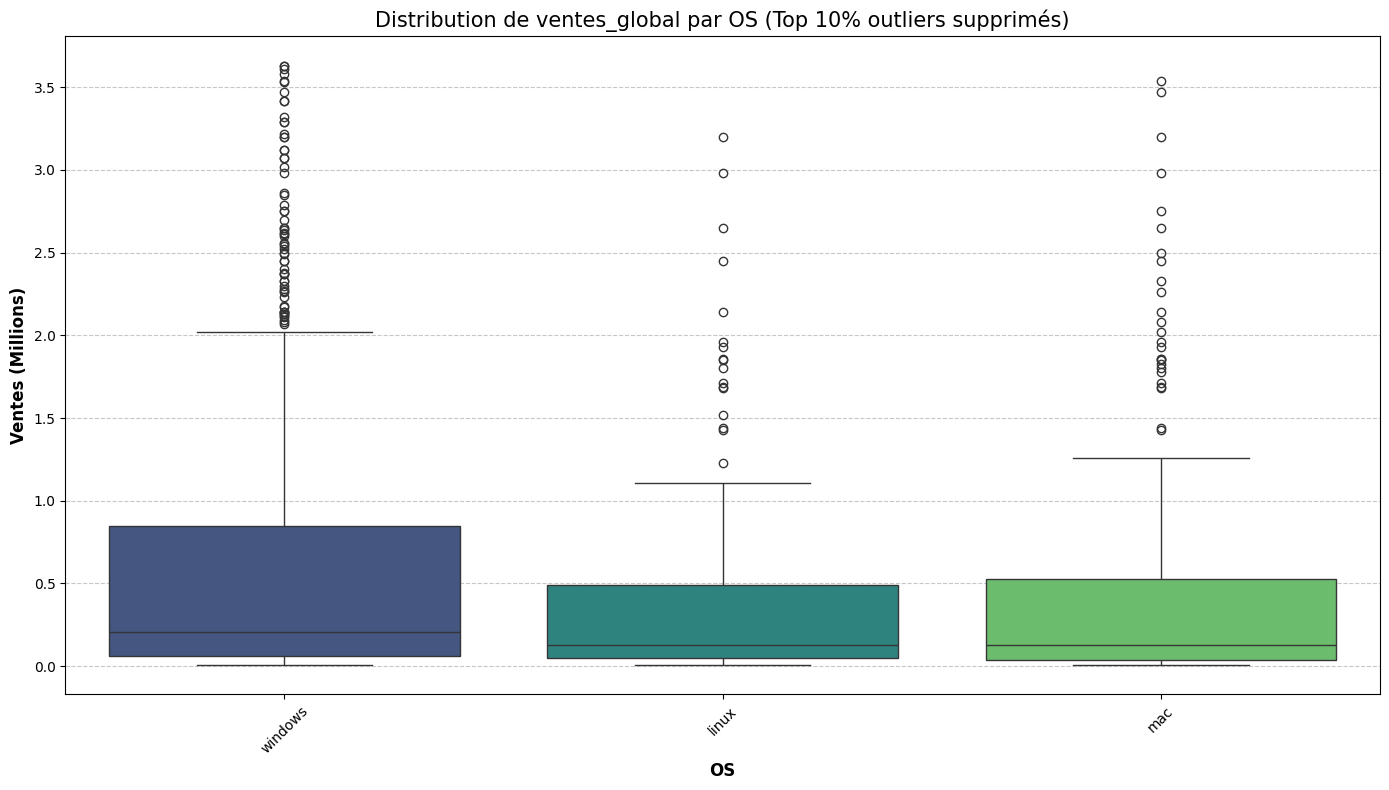

,os,ventes_global
43,mac,3.54
44,windows,3.54
48,windows,3.42
55,windows,3.20
56,windows,3.12
...,...,...
1041,windows,0.01
1042,windows,0.01
1043,linux,0.01
1044,mac,0.01


In [78]:
plot_boxplot_os('ventes_global', "OS", "Ventes (Millions)")

## OS et Ventes en Amérique du Nord

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='os', y=numeric_col, order=order, palette='viridis')


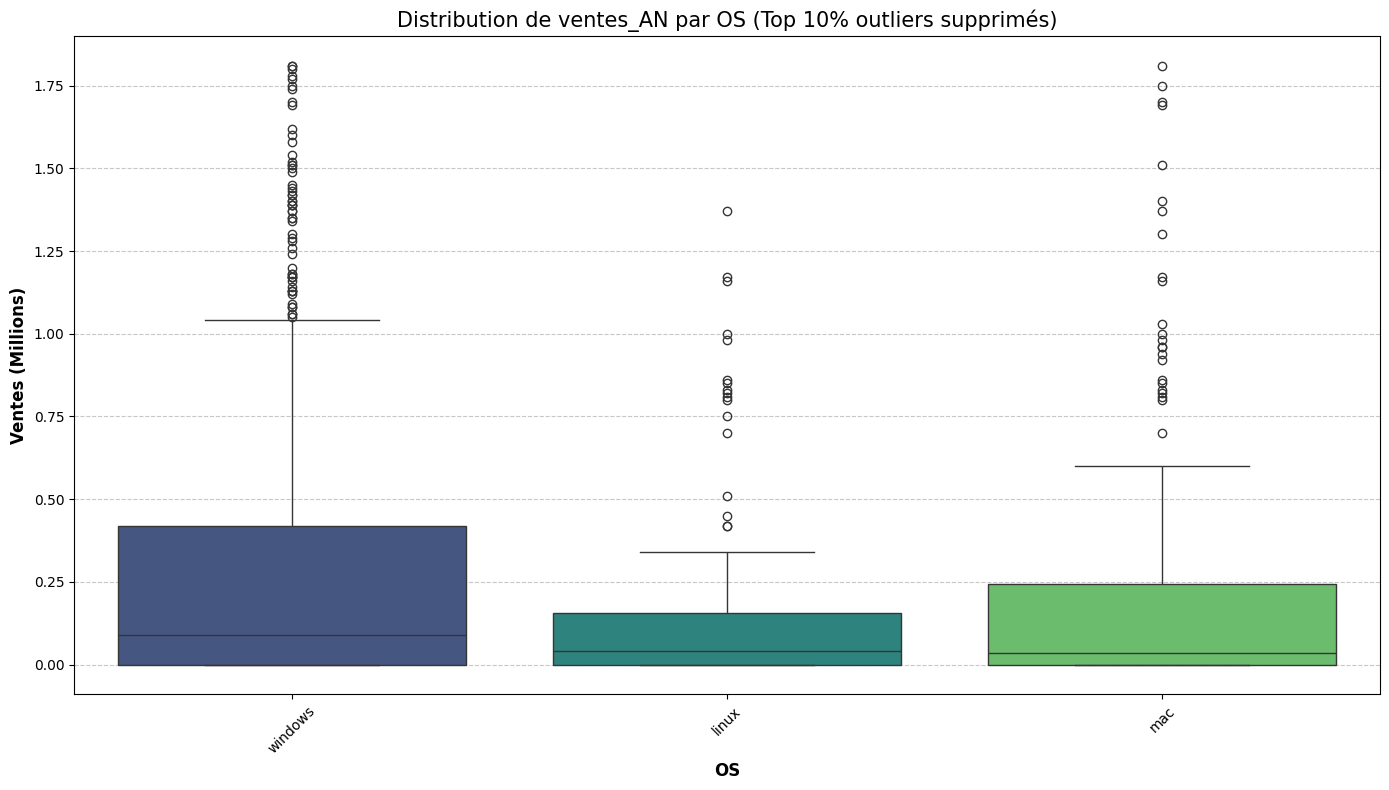

,os,ventes_AN
21,windows,1.62
48,windows,1.13
49,windows,1.77
51,windows,1.78
53,windows,1.51
...,...,...
1041,windows,0.00
1042,windows,0.00
1043,linux,0.00
1044,mac,0.00


In [79]:
plot_boxplot_os('ventes_AN', "OS", "Ventes (Millions)")

## OS et Ventes en Europe

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='os', y=numeric_col, order=order, palette='viridis')


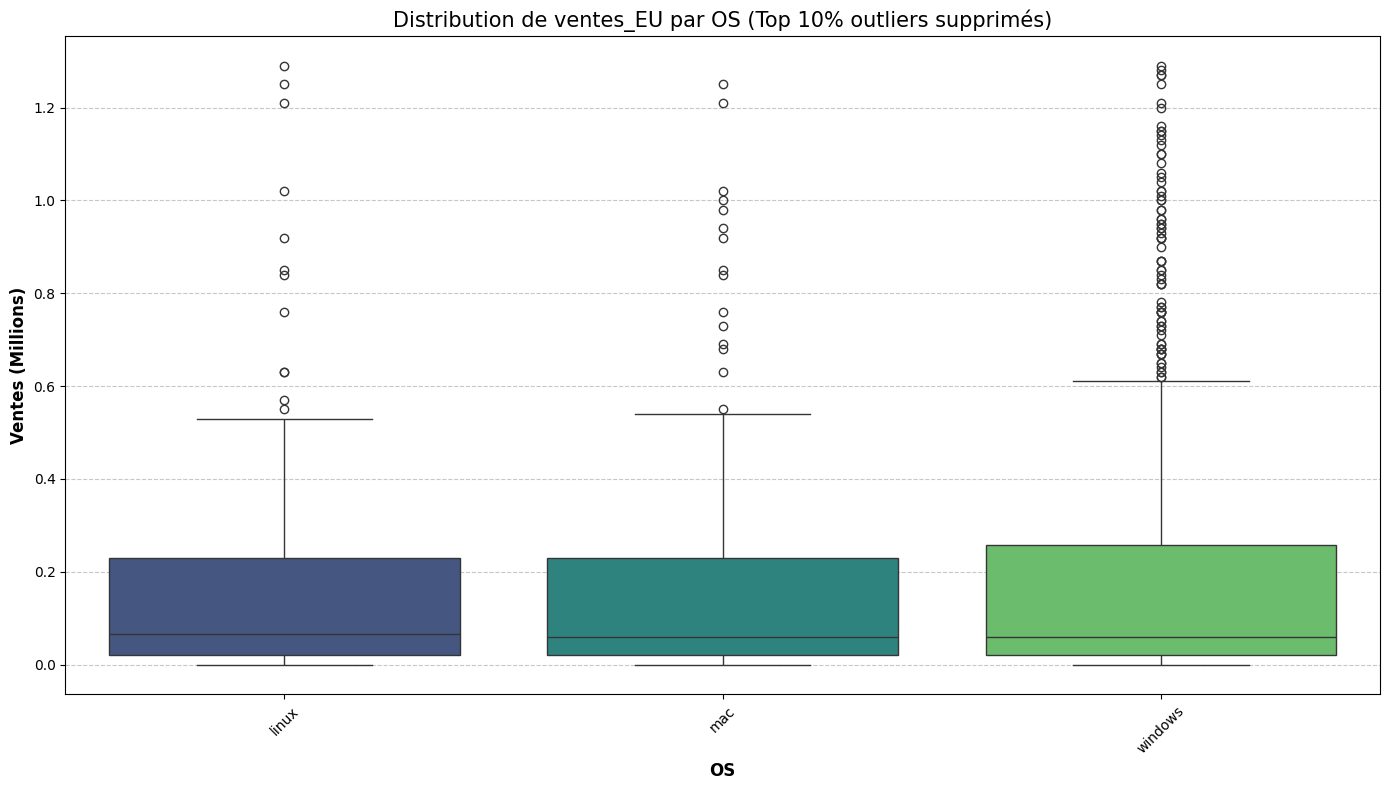

,os,ventes_EU
21,windows,0.77
29,linux,0.23
30,mac,0.23
31,windows,0.23
34,linux,1.21
...,...,...
1041,windows,0.01
1042,windows,0.01
1043,linux,0.01
1044,mac,0.01


In [80]:
plot_boxplot_os('ventes_EU', "OS", "Ventes (Millions)")

## OS et Ventes au Japon

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='os', y=numeric_col, order=order, palette='viridis')


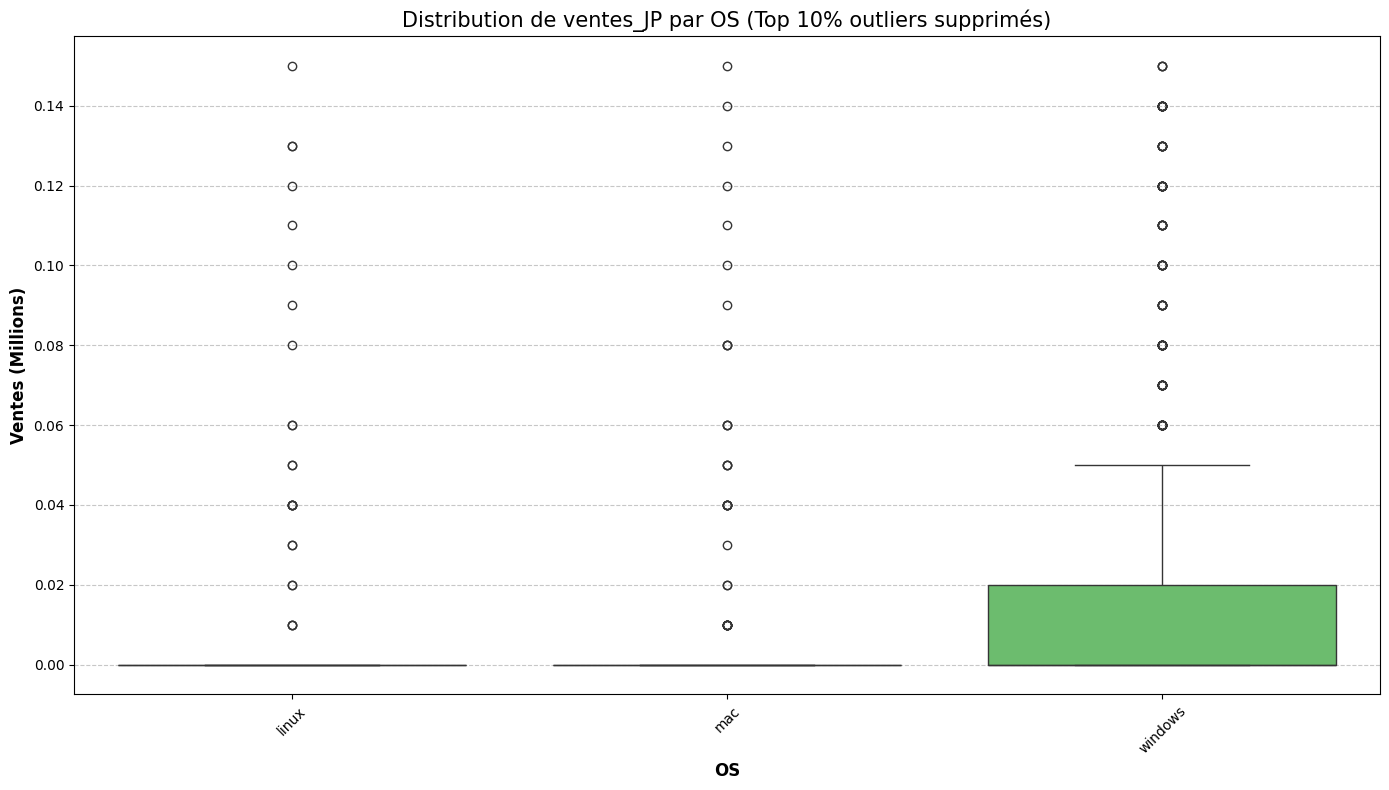

,os,ventes_JP
14,windows,0.05
16,windows,0.00
18,mac,0.00
19,windows,0.00
24,linux,0.13
...,...,...
1041,windows,0.00
1042,windows,0.00
1043,linux,0.00
1044,mac,0.00


In [81]:
plot_boxplot_os('ventes_JP', "OS", "Ventes (Millions)")

## OS et Autres Ventes

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='os', y=numeric_col, order=order, palette='viridis')


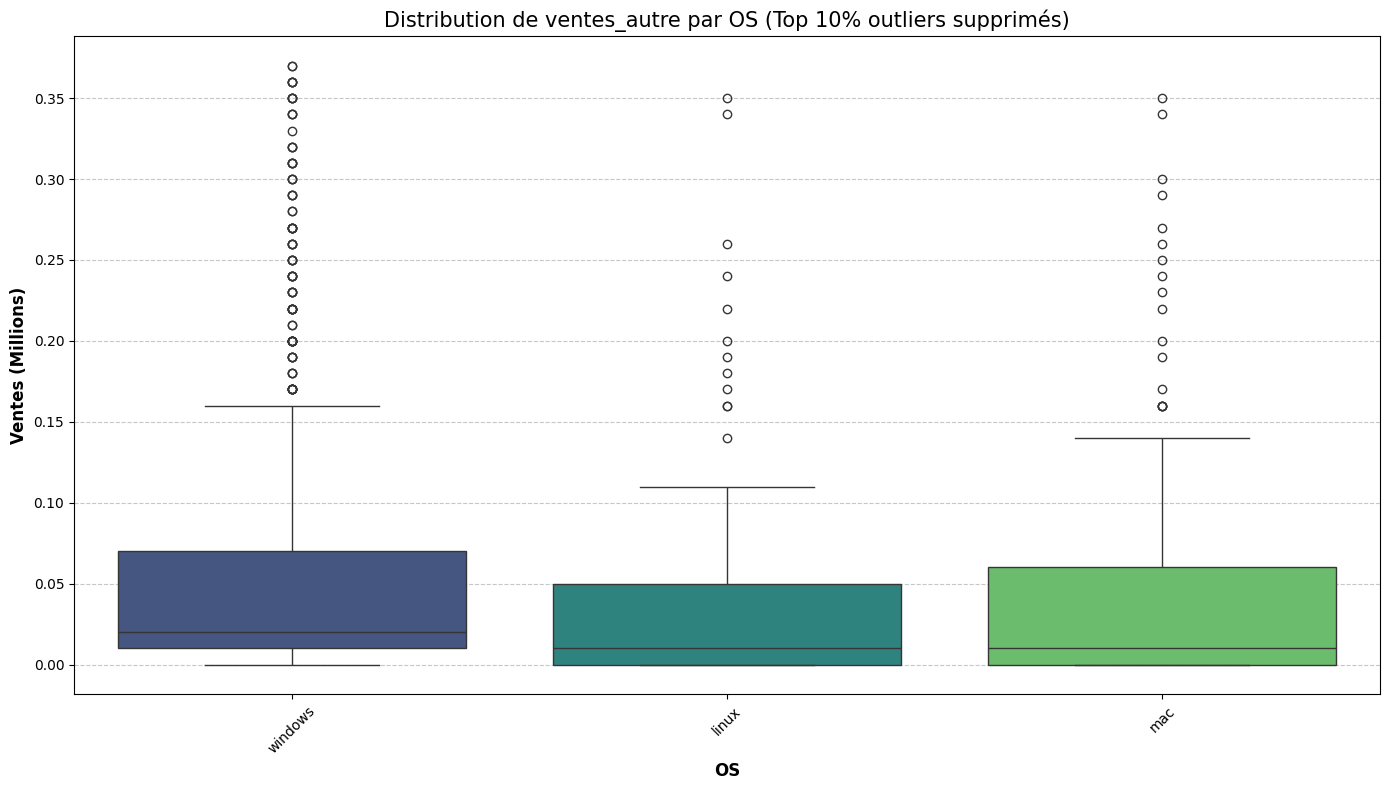

,os,ventes_autre
15,windows,0.23
21,windows,0.14
24,linux,0.24
25,mac,0.24
26,windows,0.24
...,...,...
1041,windows,0.00
1042,windows,0.00
1043,linux,0.00
1044,mac,0.00


In [82]:
plot_boxplot_os('ventes_autre', "OS", "Ventes (Millions)")

## OS et Prix

C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)
C:\Users\Ica\AppData\Local\Temp\ipykernel_2688\612439779.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='os', y=numeric_col, order=order, palette='viridis')


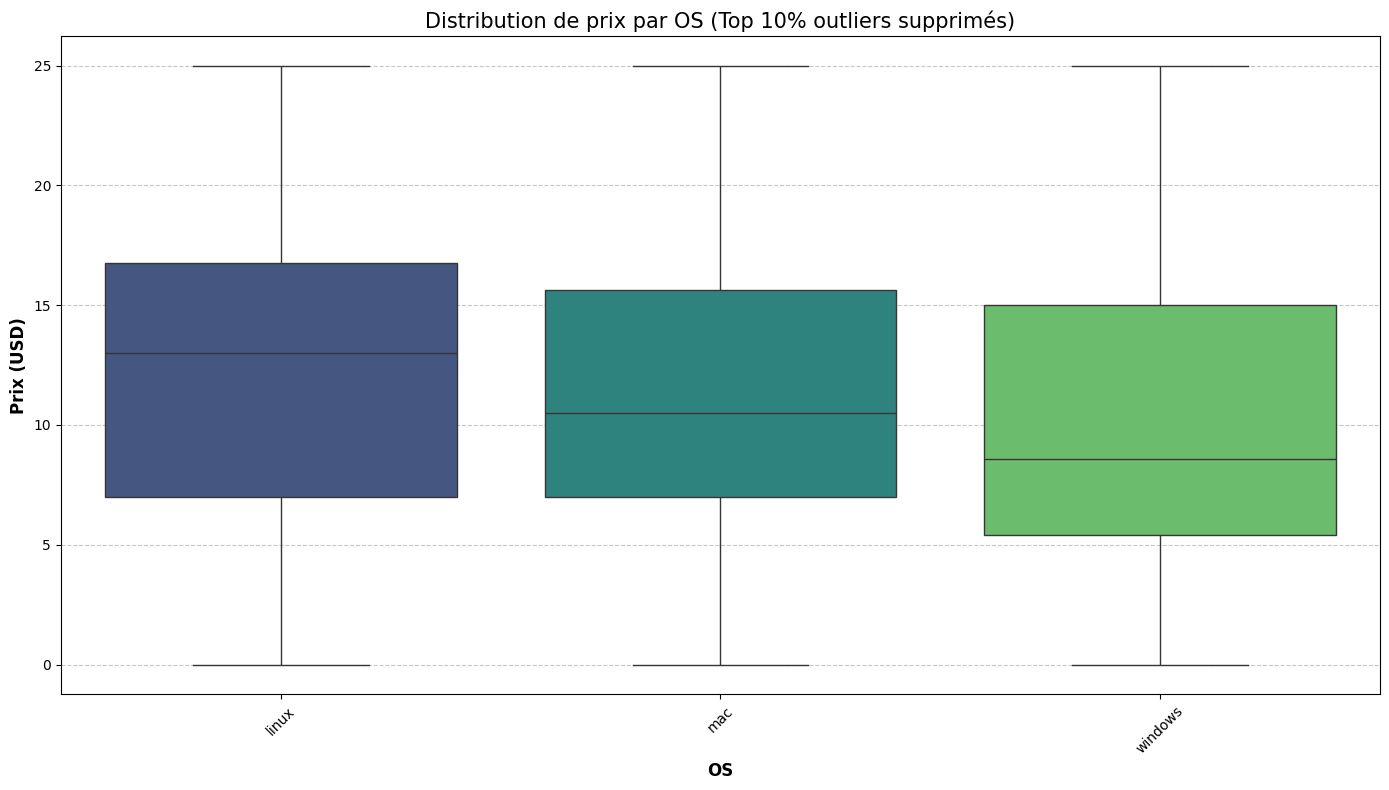

,os,prix
0,windows,24.99
1,windows,9.99
2,windows,5.99
5,mac,19.99
6,windows,19.99
...,...,...
1041,windows,9.99
1042,windows,8.99
1043,linux,6.99
1044,mac,6.99


In [83]:
plot_boxplot_os('prix', "OS", "Prix (USD)")